# Predicting Insurance Claims
---

# 1. Model training 
### a.  Missing data checking and handling

In [15]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('insurance_data.csv')
df.head()

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,...,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,...,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0


In [2]:
df.describe()

,subscription_length,vehicle_age,customer_age,region_density,airbags,displacement,cylinder,turning_radius,length,width,gross_weight,ncap_rating,claim_status
count,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000
mean,6.111688,1.388473,44.823935,18826.858667,3.137066,1162.355851,3.626963,4.852893,3850.476891,1672.233667,1385.276813,1.759950,0.063968
std,4.142790,1.134413,6.935604,17660.174792,1.832641,266.304786,0.483616,0.228061,311.457119,112.089135,212.423085,1.389576,0.244698
min,0.000000,0.000000,35.000000,290.000000,1.000000,796.000000,3.000000,4.500000,3445.000000,1475.000000,1051.000000,0.000000,0.000000
25%,2.100000,0.400000,39.000000,6112.000000,2.000000,796.000000,3.000000,4.600000,3445.000000,1515.000000,1185.000000,0.000000,0.000000
50%,5.700000,1.200000,44.000000,8794.000000,2.000000,1197.000000,4.000000,4.800000,3845.000000,1735.000000,1335.000000,2.000000,0.000000
75%,10.400000,2.200000,49.000000,27003.000000,6.000000,1493.000000,4.000000,5.000000,3995.000000,1755.000000,1510.000000,3.000000,0.000000
max,14.000000,20.000000,75.000000,73430.000000,6.000000,1498.000000,4.000000,5.200000,4300.000000,1811.000000,1720.000000,5.000000,1.000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   subscription_length               58592 non-null  float64
 2   vehicle_age                       58592 non-null  float64
 3   customer_age                      58592 non-null  int64  
 4   region_code                       58592 non-null  object 
 5   region_density                    58592 non-null  int64  
 6   segment                           58592 non-null  object 
 7   model                             58592 non-null  object 
 8   fuel_type                         58592 non-null  object 
 9   max_torque                        58592 non-null  object 
 10  max_power                         58592 non-null  object 
 11  engine_type                       58592 non-null  object 
 12  airb

##### This shows that there is no missing data.
---

### b. Duplicate data checking and handling.
i.  Dropping duplicate rows

ii.  Unique value checking and replacing any possible entity

In [4]:
df.duplicated().any()


np.False_

There is no duplicate data.

In [5]:
#df.drop_duplicates()

In [6]:
df.nunique()

policy_id                           58592
subscription_length                   140
vehicle_age                            49
customer_age                           41
region_code                            22
region_density                         22
segment                                 6
model                                  11
fuel_type                               3
max_torque                              9
max_power                               9
engine_type                            11
airbags                                 3
is_esc                                  2
is_adjustable_steering                  2
is_tpms                                 2
is_parking_sensors                      2
is_parking_camera                       2
rear_brakes_type                        2
displacement                            9
cylinder                                2
transmission_type                       2
steering_type                           3
turning_radius                    

### c.  Encoding approach

In [7]:
df.columns

Index(['policy_id', 'subscription_length', 'vehicle_age', 'customer_age',
       'region_code', 'region_density', 'segment', 'model', 'fuel_type',
       'max_torque', 'max_power', 'engine_type', 'airbags', 'is_esc',
       'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder',
       'transmission_type', 'steering_type', 'turning_radius', 'length',
       'width', 'gross_weight', 'is_front_fog_lights', 'is_rear_window_wiper',
       'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist',
       'is_power_door_locks', 'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert', 'ncap_rating', 'claim_status'],
      dtype='object')

In [8]:
df = df.drop('policy_id',axis = 1)

In [9]:
#numeric_features = ['subscription_length', 'vehicle_age', 'customer_age', 'model', 'displacement']
cat_features = ['fuel_type','engine_type', 'region_code','airbags', 'is_front_fog_lights', 'is_rear_window_wiper',
       'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'model',
       'is_power_door_locks', 'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror','is_ecw', 'is_speed_alert']

In [10]:
le = LabelEncoder()
#df_encoded=pd.get_dummies(df, cat_= cat_features, drop_first =True)
for feature in cat_features:
    df[feature] = le.fit_transform(df[feature])

df

,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,max_power,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,9.3,1.2,41,20,8794,C2,5,1,250Nm@2750rpm,113.45bhp@4000rpm,...,1,1,1,1,1,0,1,1,3,0
1,8.2,1.8,35,11,27003,C1,10,1,200Nm@1750rpm,97.89bhp@3600rpm,...,0,1,1,1,1,1,1,1,4,0
2,9.5,0.2,44,20,8794,C2,5,1,250Nm@2750rpm,113.45bhp@4000rpm,...,1,1,1,1,1,0,1,1,3,0
3,5.2,0.4,44,1,73430,A,0,0,60Nm@3500rpm,40.36bhp@6000rpm,...,0,0,0,1,0,0,0,1,0,0
4,10.1,1.0,56,4,5410,B2,6,1,200Nm@3000rpm,88.77bhp@4000rpm,...,0,1,1,1,0,0,1,1,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58587,10.6,2.6,48,17,34738,B2,7,2,113Nm@4400rpm,88.50bhp@6000rpm,...,1,1,1,1,1,1,1,1,2,0
58588,2.3,2.2,37,15,4076,C2,5,1,250Nm@2750rpm,113.45bhp@4000rpm,...,1,1,1,1,1,0,1,1,3,0
58589,6.6,2.2,35,20,8794,B2,7,2,113Nm@4400rpm,88.50bhp@6000rpm,...,1,1,1,1,1,1,1,1,2,0
58590,4.1,3.6,44,20,8794,B2,7,2,113Nm@4400rpm,88.50bhp@6000rpm,...,1,1,1,1,1,1,1,1,2,0


In [11]:
numeric_features = ['subscription_length', 'vehicle_age', 'customer_age', 'displacement', 'gross_weight','region_density']

In [12]:
'''df=pd.get_dummies(df, drop_first = 'true')
df'''

"df=pd.get_dummies(df, drop_first = 'true')\ndf"

### Checking Outliers

In [13]:
for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    print("Number of outliers:", feature, len(outliers))
    df = df[(df[feature]>= lower_bound) & (df[feature]<= upper_bound)]

print("after removal, number of datas =",len(df))
    
df.shape

Number of outliers: subscription_length 0
Number of outliers: vehicle_age 269
Number of outliers: customer_age 279
Number of outliers: displacement 0
Number of outliers: gross_weight 0
Number of outliers: region_density 3621
after removal, number of datas = 54423


(54423, 40)

##### Data containing outliers are comparatively lesser(<5000) than the total number of  data(>58000). Hence, the samples were dropped to remove the outlier.

fuel_type
2    19236
0    18496
1    16691
Name: count, dtype: int64


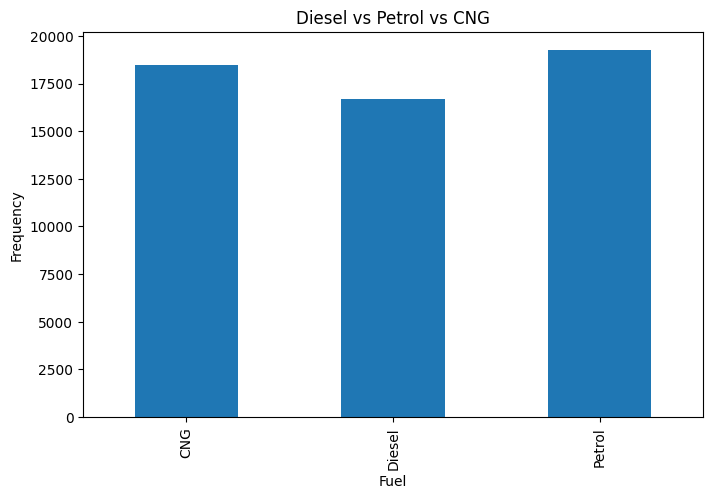

In [14]:
print(df['fuel_type'].value_counts())
plt.figure(figsize=(8, 5))
df['fuel_type'].value_counts().sort_index().plot(kind='bar')
plt.title('Diesel vs Petrol vs CNG')
plt.xticks([0, 1, 2], ['CNG', 'Diesel', 'Petrol'])
plt.xlabel('Fuel')
plt.ylabel('Frequency')
plt.show()


[9.3, 8.2, 9.5, 10.1, 3.1, 4.5, 10.7, 10.7, 0.3, 10.5, 5.3, 10.2, 1.4, 5.6, 10.3, 8.8, 2.4, 9.7, 11.6, 5.3, 10.2, 0.9, 1.2, 1.3, 12.4, 6.8, 0.7, 12.4, 7.7, 8.3, 0.8, 10.6, 2.8, 0.2, 11.8, 6.4, 4.3, 12.1, 5.5, 2.6, 0.9, 10.1, 1.8, 4.6, 2.7, 10.9, 0.9, 2.2, 0.4, 11.7, 10.6, 12.2, 0.8, 3.8, 0.5, 5.0, 1.3, 0.6, 1.0, 0.2, 1.1, 4.9, 1.5, 2.8, 11.2, 12.4, 1.0, 8.2, 4.3, 1.8, 11.1, 5.0, 12.2, 10.6, 0.2, 1.1, 11.1, 10.7, 6.8, 1.1, 11.8, 8.5, 0.1, 5.3, 0.4, 3.1, 7.4, 4.4, 7.7, 2.1, 3.8, 2.2, 7.6, 11.7, 0.9, 5.1, 1.0, 5.7, 0.9, 8.8, 3.4, 0.2, 0.4, 5.6, 2.7, 3.8, 3.2, 11.1, 2.2, 1.4, 8.1, 1.1, 3.0, 8.7, 6.5, 2.8, 2.2, 12.2, 10.4, 10.3, 9.2, 10.5, 9.6, 0.1, 6.8, 2.8, 10.8, 5.7, 10.8, 6.4, 11.6, 3.8, 10.4, 3.8, 3.5, 11.8, 10.3, 11.9, 6.4, 0.0, 8.6, 0.4, 2.4, 10.9, 5.4, 9.0, 10.1, 8.7, 6.6, 10.3, 8.6, 0.9, 12.3, 1.3, 6.3, 2.4, 10.2, 6.6, 5.8, 11.2, 0.1, 7.1, 0.3, 2.9, 0.4, 11.3, 11.1, 3.6, 0.4, 0.8, 10.8, 4.3, 11.3, 10.0, 0.9, 10.1, 1.7, 12.3, 7.3, 2.2, 8.9, 2.6, 10.1, 11.4, 3.0, 0.8, 2.5, 8.7, 1.6, 

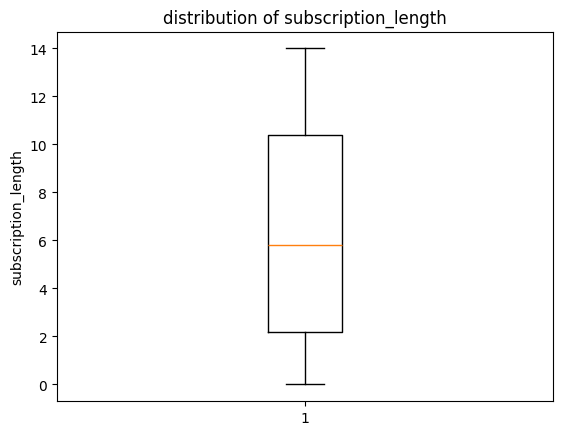

[1.2, 1.8, 0.2, 1.0, 2.0, 2.4, 2.0, 0.6, 2.4, 3.0, 1.2, 1.6, 0.0, 0.2, 3.8, 0.4, 2.8, 1.0, 0.4, 0.8, 1.0, 1.4, 0.2, 0.0, 2.0, 1.4, 0.0, 0.6, 0.0, 1.2, 0.6, 0.8, 1.2, 1.4, 2.0, 2.2, 2.0, 3.8, 0.6, 0.4, 2.2, 2.8, 1.0, 1.2, 0.0, 2.0, 0.4, 3.2, 0.4, 1.2, 3.6, 3.2, 1.4, 2.0, 2.0, 1.4, 3.2, 0.0, 0.4, 0.2, 0.4, 1.4, 1.0, 0.2, 0.4, 2.0, 1.2, 0.2, 2.0, 1.6, 1.4, 1.4, 0.4, 1.6, 1.0, 1.0, 1.0, 2.2, 0.6, 0.0, 1.6, 0.2, 0.0, 0.4, 2.6, 2.6, 0.2, 0.4, 0.8, 0.4, 0.6, 2.4, 1.2, 1.4, 3.0, 0.2, 1.6, 0.0, 3.6, 2.6, 0.2, 2.8, 0.4, 0.6, 0.2, 1.8, 0.8, 2.8, 2.4, 0.8, 1.8, 1.0, 2.4, 0.8, 0.4, 2.4, 0.2, 3.0, 0.4, 0.2, 2.2, 1.0, 0.4, 0.8, 0.2, 1.4, 0.6, 1.0, 1.4, 1.4, 0.4, 0.6, 0.2, 2.0, 3.2, 1.0, 2.4, 1.6, 0.4, 0.8, 0.2, 0.2, 0.6, 1.8, 0.2, 0.8, 2.8, 0.0, 0.2, 1.2, 0.8, 2.2, 1.8, 0.4, 1.0, 1.2, 0.0, 2.4, 1.8, 0.4, 1.0, 1.6, 1.4, 2.0, 0.0, 2.2, 2.0, 0.4, 0.2, 2.4, 1.6, 0.2, 0.6, 2.4, 0.8, 0.2, 0.6, 3.6, 2.6, 3.2, 1.0, 1.6, 2.4, 1.8, 0.8, 1.6, 2.0, 0.6, 0.6, 0.8, 0.2, 3.2, 2.6, 1.6, 2.0, 2.4, 2.8, 0.8, 0.0, 2.4,

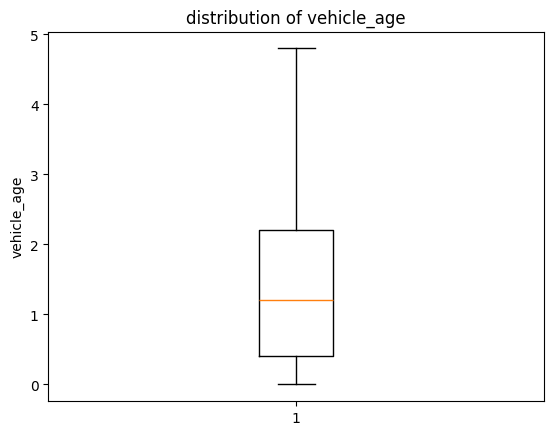

[41, 35, 44, 56, 36, 38, 56, 55, 45, 37, 39, 41, 44, 36, 40, 40, 42, 43, 48, 45, 41, 36, 53, 46, 44, 51, 37, 44, 45, 43, 41, 38, 36, 40, 37, 44, 35, 38, 61, 39, 44, 50, 35, 35, 49, 35, 36, 47, 53, 39, 47, 52, 52, 42, 48, 44, 47, 49, 43, 46, 40, 52, 44, 37, 57, 36, 37, 45, 36, 52, 37, 52, 41, 43, 40, 40, 57, 40, 49, 53, 53, 58, 53, 53, 40, 45, 40, 43, 40, 39, 45, 41, 57, 55, 35, 40, 43, 40, 44, 60, 57, 35, 47, 45, 45, 41, 38, 36, 40, 51, 40, 39, 48, 56, 36, 44, 41, 57, 45, 39, 45, 36, 44, 41, 44, 36, 51, 42, 38, 35, 53, 47, 36, 44, 43, 40, 40, 48, 38, 47, 43, 39, 57, 48, 42, 53, 43, 51, 41, 51, 45, 48, 45, 35, 40, 43, 37, 35, 37, 54, 39, 50, 48, 41, 38, 39, 54, 42, 46, 35, 45, 50, 60, 49, 35, 44, 50, 52, 45, 48, 44, 40, 51, 43, 43, 38, 46, 47, 39, 52, 47, 44, 36, 54, 43, 51, 60, 39, 39, 41, 45, 47, 45, 54, 59, 44, 40, 42, 47, 45, 41, 43, 35, 45, 37, 46, 43, 48, 41, 42, 37, 49, 36, 50, 48, 49, 49, 40, 52, 44, 39, 40, 40, 35, 40, 37, 38, 51, 47, 63, 44, 45, 37, 35, 48, 54, 40, 39, 44, 44,

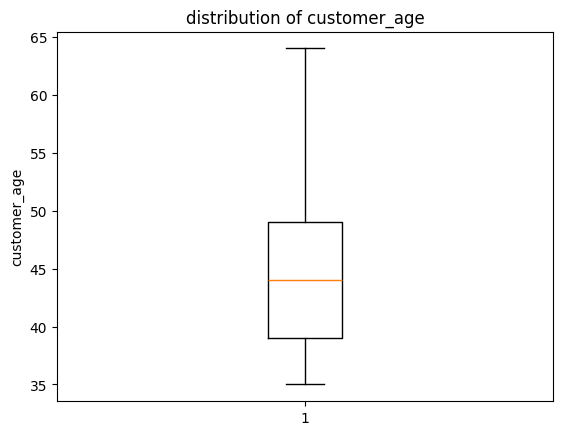

[1493, 1498, 1493, 1497, 1197, 1493, 1197, 998, 1197, 1197, 796, 1493, 796, 796, 1197, 796, 1197, 999, 1197, 1197, 1493, 1493, 796, 796, 1498, 998, 796, 1197, 796, 1197, 998, 796, 1197, 1197, 1493, 999, 1197, 1197, 796, 796, 1493, 1197, 1493, 796, 1196, 999, 1197, 1197, 796, 1197, 1197, 1197, 1493, 1197, 1493, 1197, 1493, 796, 1197, 796, 1498, 1197, 1197, 796, 796, 1197, 1197, 1197, 796, 1196, 1493, 1197, 1498, 1197, 796, 1493, 998, 1493, 1493, 796, 1493, 796, 796, 796, 1197, 1197, 796, 796, 1497, 998, 1493, 1196, 796, 1493, 1493, 796, 1196, 796, 1493, 1197, 1197, 998, 796, 1493, 796, 998, 796, 1493, 1197, 796, 1493, 1498, 1197, 1493, 796, 998, 796, 1493, 1197, 1197, 1197, 999, 796, 1199, 1497, 1493, 796, 1199, 1197, 1197, 1498, 796, 1497, 1197, 999, 1197, 1493, 999, 796, 1493, 796, 796, 796, 998, 796, 1197, 1493, 796, 1197, 1197, 796, 1197, 1493, 796, 1197, 1493, 1493, 1493, 998, 796, 1197, 1498, 1197, 1493, 796, 1197, 1197, 796, 1197, 1493, 1197, 796, 1197, 1197, 1197, 1493, 1196, 14

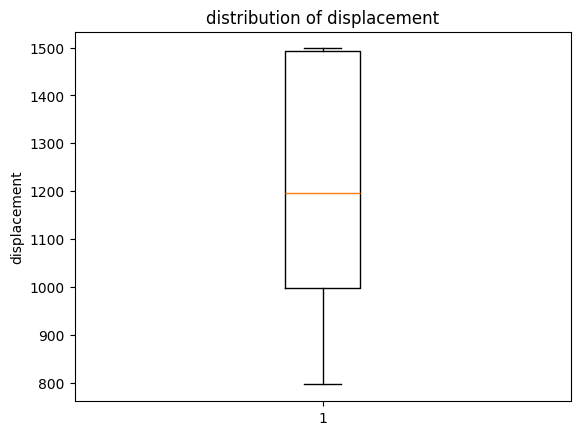

[1720, 1051, 1720, 1490, 1410, 1720, 1335, 1340, 1335, 1335, 1185, 1720, 1185, 1185, 1335, 1185, 1335, 1155, 1410, 1335, 1720, 1720, 1185, 1185, 1051, 1340, 1185, 1335, 1185, 1410, 1340, 1185, 1335, 1335, 1720, 1155, 1335, 1410, 1185, 1185, 1720, 1335, 1720, 1185, 1510, 1155, 1335, 1335, 1185, 1335, 1335, 1335, 1720, 1410, 1720, 1335, 1720, 1185, 1335, 1185, 1051, 1335, 1335, 1185, 1185, 1335, 1335, 1335, 1185, 1510, 1720, 1410, 1051, 1410, 1185, 1720, 1340, 1720, 1720, 1185, 1720, 1185, 1185, 1185, 1335, 1335, 1185, 1185, 1490, 1340, 1720, 1510, 1185, 1720, 1720, 1185, 1510, 1185, 1720, 1335, 1335, 1340, 1185, 1720, 1185, 1340, 1185, 1720, 1335, 1185, 1720, 1051, 1335, 1720, 1185, 1340, 1185, 1720, 1335, 1335, 1335, 1155, 1185, 1660, 1490, 1720, 1185, 1660, 1335, 1410, 1051, 1185, 1490, 1335, 1155, 1335, 1720, 1155, 1185, 1720, 1185, 1185, 1185, 1340, 1185, 1335, 1720, 1185, 1335, 1335, 1185, 1335, 1720, 1185, 1335, 1720, 1720, 1720, 1340, 1185, 1335, 1051, 1335, 1720, 1185, 1335, 133

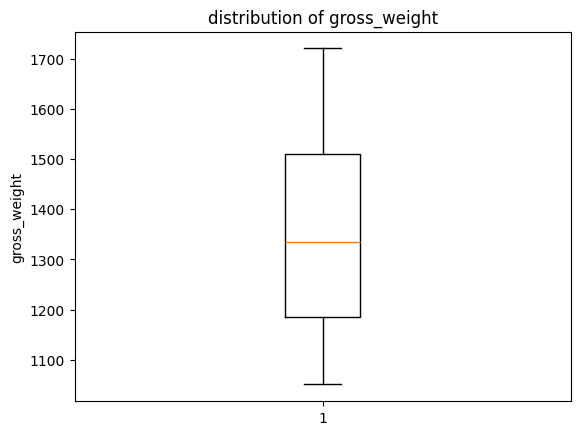

[8794, 27003, 8794, 5410, 6112, 27003, 27003, 34738, 4076, 27742, 8794, 27003, 27003, 4076, 8794, 17804, 27003, 290, 5410, 34738, 27003, 27003, 13051, 4076, 4076, 27003, 4076, 8794, 4076, 27003, 4076, 27003, 8794, 5410, 8794, 27003, 5410, 5410, 4076, 34738, 17804, 27003, 8794, 27742, 4076, 17804, 27003, 8794, 34738, 290, 4076, 5410, 8794, 6108, 8794, 13051, 27742, 5410, 5410, 4990, 34738, 34738, 27003, 6112, 17804, 7788, 6108, 27003, 290, 27003, 4076, 8794, 27003, 27003, 4076, 8794, 34738, 8794, 5410, 4076, 8794, 4076, 4076, 34738, 7788, 4076, 27003, 34738, 7788, 290, 27003, 8794, 34738, 8794, 6112, 34738, 27003, 34791, 21622, 7788, 4076, 27003, 34738, 8794, 13051, 4076, 4076, 3264, 34738, 4076, 8794, 34738, 8794, 27742, 4990, 17804, 27003, 13051, 8794, 27003, 13051, 5410, 4076, 16206, 8794, 8794, 8794, 5410, 4076, 8794, 6108, 17804, 8794, 27003, 4076, 4076, 7788, 8794, 4076, 5410, 34738, 4076, 34738, 34738, 4990, 34738, 7788, 34738, 8794, 6108, 34738, 5410, 8794, 34791, 4990, 34738, 2

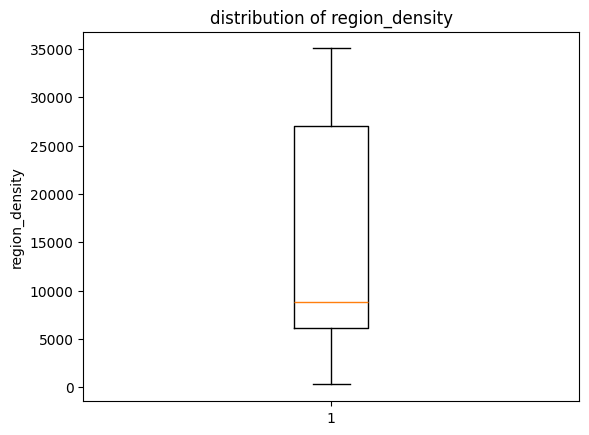

In [15]:
for feature in numeric_features:
    print(value := df[feature].tolist())
    plt.boxplot(value)
    plt.title(f'distribution of {feature}')
    plt.ylabel(feature)
    plt.show()

### No outliers remaining.

In [16]:
for feature in numeric_features:
    min_ = df[feature].min()
    max_ = df[feature].max()
    df[feature] = (df[feature] - min_) / (max_ - min_)
df

,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,max_power,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,0.664286,0.250000,0.206897,20,0.244748,C2,5,1,250Nm@2750rpm,113.45bhp@4000rpm,...,1,1,1,1,1,0,1,1,3,0
1,0.585714,0.375000,0.000000,11,0.768808,C1,10,1,200Nm@1750rpm,97.89bhp@3600rpm,...,0,1,1,1,1,1,1,1,4,0
2,0.678571,0.041667,0.310345,20,0.244748,C2,5,1,250Nm@2750rpm,113.45bhp@4000rpm,...,1,1,1,1,1,0,1,1,3,0
4,0.721429,0.208333,0.724138,4,0.147355,B2,6,1,200Nm@3000rpm,88.77bhp@4000rpm,...,0,1,1,1,0,0,1,1,5,0
5,0.221429,0.416667,0.034483,19,0.167559,B2,8,2,113Nm@4400rpm,88.50bhp@6000rpm,...,1,1,1,1,1,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58587,0.757143,0.541667,0.448276,17,0.991423,B2,7,2,113Nm@4400rpm,88.50bhp@6000rpm,...,1,1,1,1,1,1,1,1,2,0
58588,0.164286,0.458333,0.068966,15,0.108962,C2,5,1,250Nm@2750rpm,113.45bhp@4000rpm,...,1,1,1,1,1,0,1,1,3,0
58589,0.471429,0.458333,0.000000,20,0.244748,B2,7,2,113Nm@4400rpm,88.50bhp@6000rpm,...,1,1,1,1,1,1,1,1,2,0
58590,0.292857,0.750000,0.310345,20,0.244748,B2,7,2,113Nm@4400rpm,88.50bhp@6000rpm,...,1,1,1,1,1,1,1,1,2,0


In [17]:
print(df['ncap_rating'].value_counts())

ncap_rating
2    20070
0    17330
3    13217
4     1991
5     1815
Name: count, dtype: int64


### e. Assigned EDA
#### 1. Target Variable Analysis (claim_status) 

In [18]:
print(df['claim_status'].value_counts())

claim_status
0    50886
1     3537
Name: count, dtype: int64


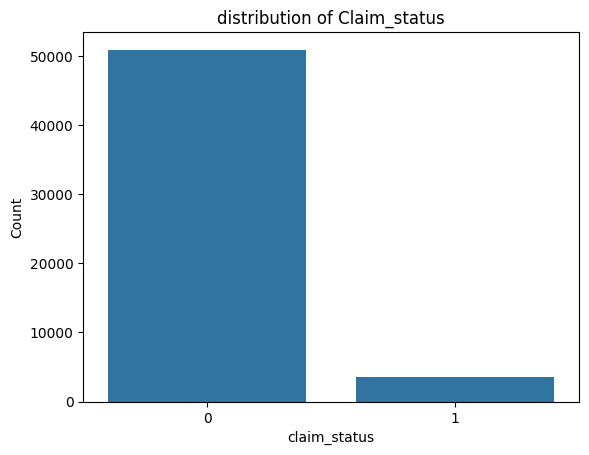

In [19]:
plt.figure('figsize(5,5)')
sns.countplot(x = "claim_status", data = df)
plt.title(f'distribution of Claim_status')
plt.ylabel('Count')
plt.show()



##### Count plot of Claim_status shows heavy imbalance in distribution.
##### Resampling Plan: Apply SMOTE (Synthetic Minority Oversampling Technique) to balance the classes.

=== Claim Status Distribution ===
Not Claimed (0): 50886  (93.50%)
Claimed     (1): 3537  (6.50%)

Imbalance Ratio (majority:minority): 14.39 : 1


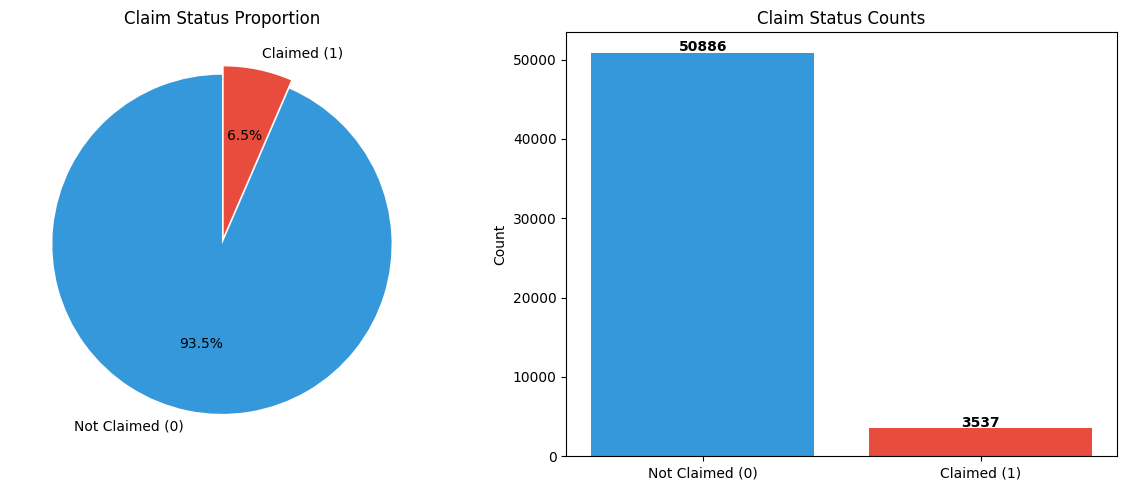

In [20]:
# Detailed class distribution analysis
counts = df['claim_status'].value_counts()
percentages = df['claim_status'].value_counts(normalize=True) * 100
imbalance_ratio = counts[0] / counts[1]

print("=== Claim Status Distribution ===")
print(f"Not Claimed (0): {counts[0]}  ({percentages[0]:.2f}%)")
print(f"Claimed     (1): {counts[1]}  ({percentages[1]:.2f}%)")
print(f"\nImbalance Ratio (majority:minority): {imbalance_ratio:.2f} : 1")

# Pie chart for visual proportion
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(counts, labels=['Not Claimed (0)', 'Claimed (1)'], autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c'], startangle=90, explode=(0, 0.05))
axes[0].set_title('Claim Status Proportion')

# Bar chart with counts annotated
bars = axes[1].bar(['Not Claimed (0)', 'Claimed (1)'], counts, color=['#3498db', '#e74c3c'])
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 str(count), ha='center', fontweight='bold')
axes[1].set_title('Claim Status Counts')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Encoding remaining string columns: ['segment', 'max_torque', 'max_power', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'transmission_type', 'steering_type']

=== Before SMOTE ===
claim_status
0    50886
1     3537
Name: count, dtype: int64

=== After SMOTE ===
claim_status
0    50886
1    50886
Name: count, dtype: int64


C:\Users\Acer\AppData\Local\Temp\ipykernel_42568\954185690.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, ax=axes[0], palette=['#3498db', '#e74c3c'])
C:\Users\Acer\AppData\Local\Temp\ipykernel_42568\954185690.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, ax=axes[1], palette=['#3498db', '#e74c3c'])


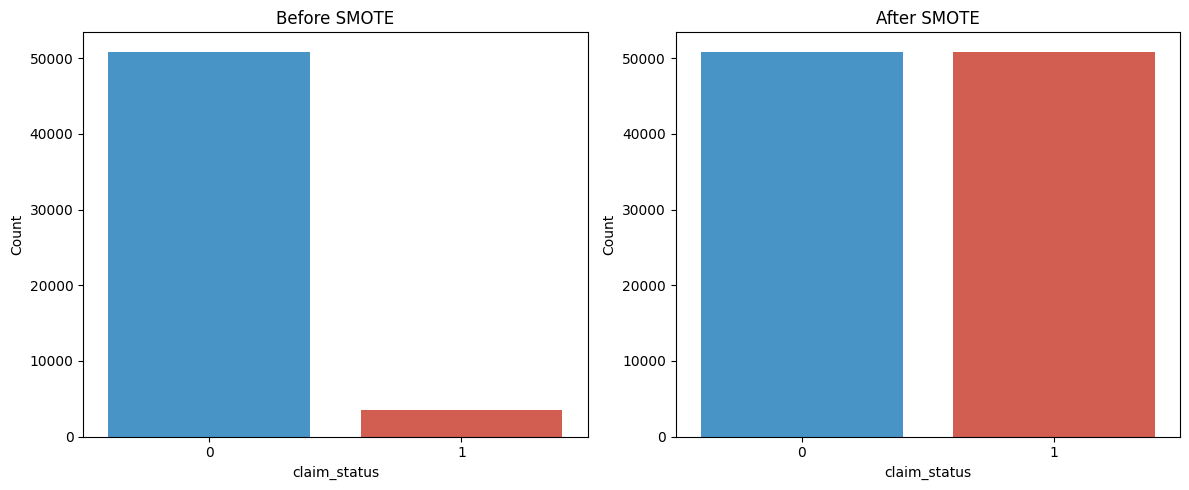


Dataset size: 54423 = 101772 samples


In [21]:
# Apply SMOTE to balance the classes
from imblearn.over_sampling import SMOTE

# Encode remaining non-numeric columns for SMOTE
df_smote = df.copy()
remaining_obj_cols = df_smote.select_dtypes(include='object').columns.tolist()
if remaining_obj_cols:
    print(f"Encoding remaining string columns: {remaining_obj_cols}")
    for col in remaining_obj_cols:
        df_smote[col] = LabelEncoder().fit_transform(df_smote[col])

X = df_smote.drop('claim_status', axis=1)
y = df_smote['claim_status']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Verify distribution after SMOTE
print("\n=== Before SMOTE ===")
print(y.value_counts())
print(f"\n=== After SMOTE ===")
print(y_resampled.value_counts())

# Compare distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y, ax=axes[0], palette=['#3498db', '#e74c3c'])
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('claim_status')
axes[0].set_ylabel('Count')

sns.countplot(x=y_resampled, ax=axes[1], palette=['#3498db', '#e74c3c'])
axes[1].set_title('After SMOTE')
axes[1].set_xlabel('claim_status')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"\nDataset size: {len(y)} = {len(y_resampled)} samples")

In [22]:
df.shape
print({len(y_resampled)})


{101772}


### 2. Demographic & Customer Analysis
Analyze `customer_age`, `region_code`, `region_density`, and `segment` vs `claim_status`, identify high-risk groups, and compare urban vs rural claim patterns.

=== Claim Rate by Segment ===
         claim_rate  total_customers  total_claims  claim_rate_pct
segment                                                           
B2         0.068581            18314          1256            6.86
C2         0.064275            14018           901            6.43
C1         0.064099             3557           228            6.41
A          0.060389            17321          1046            6.04
Utility    0.060380             1209            73            6.04
B1         0.058471             4173           244            5.85

=== Claim Rate by Region Code (Top 15 by claim rate; min 30 customers) ===
             claim_rate  total_customers  total_claims  claim_rate_pct
region_code                                                           
C18            0.107438              242            26           10.74
C22            0.082126              207            17            8.21
C14            0.076776             3660           281            7.68
C4 

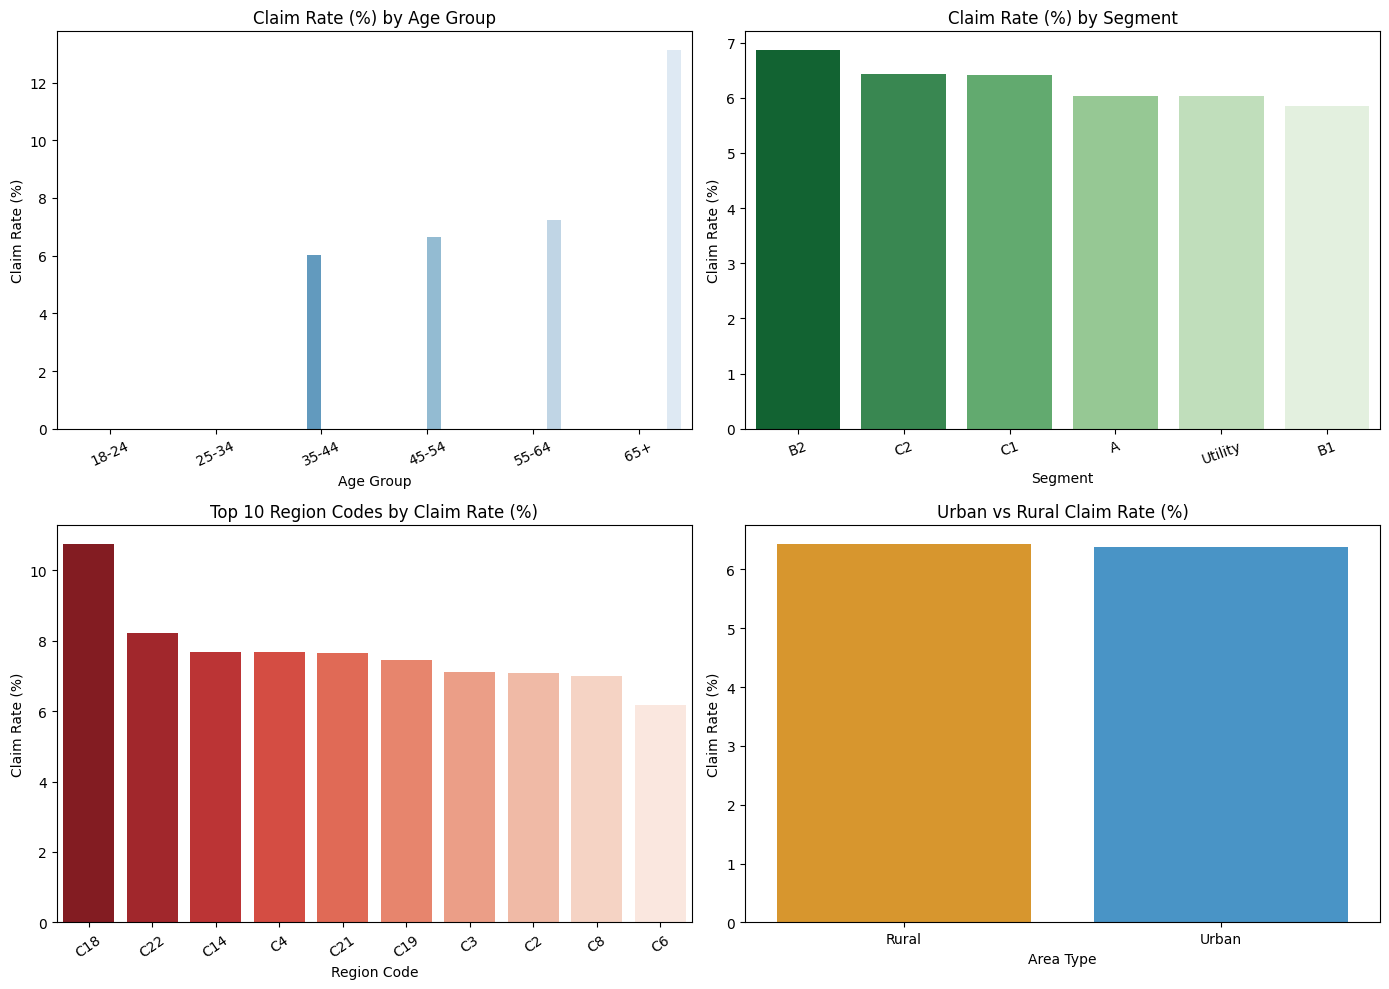

In [4]:
# Question 2: Demographic & Customer Analysis
analysis_df = df.copy()

# Ensure required columns exist
required_cols = ['customer_age', 'region_code', 'region_density', 'segment', 'claim_status']
missing_cols = [c for c in required_cols if c not in analysis_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for Q2: {missing_cols}")

# Convert claim_status to numeric if needed
analysis_df['claim_status'] = pd.to_numeric(analysis_df['claim_status'], errors='coerce')
analysis_df = analysis_df.dropna(subset=['claim_status'])
analysis_df['claim_status'] = analysis_df['claim_status'].astype(int)

# 1) Analyze customer_age, region_code, region_density, segment vs claim_status
print('=== Claim Rate by Segment ===')
segment_claim = (
    analysis_df.groupby('segment')['claim_status']
    .agg(claim_rate='mean', total_customers='count', total_claims='sum')
    .sort_values('claim_rate', ascending=False)
)
segment_claim['claim_rate_pct'] = (segment_claim['claim_rate'] * 100).round(2)
print(segment_claim)

print('\n=== Claim Rate by Region Code (Top 15 by claim rate; min 30 customers) ===')
region_claim = (
    analysis_df.groupby('region_code')['claim_status']
    .agg(claim_rate='mean', total_customers='count', total_claims='sum')
)
region_claim = region_claim[region_claim['total_customers'] >= 30].sort_values('claim_rate', ascending=False)
region_claim['claim_rate_pct'] = (region_claim['claim_rate'] * 100).round(2)
print(region_claim.head(15))

print('\n=== Claim Rate by Age Group ===')
age_bins = [18, 25, 35, 45, 55, 65, 100]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
analysis_df['age_group'] = pd.cut(
    analysis_df['customer_age'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True,
    right=False
)
age_claim = (
    analysis_df.groupby('age_group', observed=False)['claim_status']
    .agg(claim_rate='mean', total_customers='count', total_claims='sum')
)
age_claim = age_claim[age_claim['total_customers'] > 0].sort_values('claim_rate', ascending=False)
age_claim['claim_rate_pct'] = (age_claim['claim_rate'] * 100).round(2)
print(age_claim)

# 2) Identify age groups or segments with higher claim probability
print('\n=== Higher Claim Probability Groups ===')
print(f"Highest-risk age group: {age_claim.index[0]} ({age_claim.iloc[0]['claim_rate_pct']}%)")
print(f"Highest-risk segment: {segment_claim.index[0]} ({segment_claim.iloc[0]['claim_rate_pct']}%)")

# 3) Compare urban vs rural claim patterns using region_density
# Rule: density >= median -> Urban, else Rural
density_threshold = analysis_df['region_density'].median()
analysis_df['area_type'] = analysis_df['region_density'].apply(
    lambda x: 'Urban' if x >= density_threshold else 'Rural'
)

area_claim = (
    analysis_df.groupby('area_type')['claim_status']
    .agg(claim_rate='mean', total_customers='count', total_claims='sum')
    .sort_values('claim_rate', ascending=False)
)
area_claim['claim_rate_pct'] = (area_claim['claim_rate'] * 100).round(2)

print('\n=== Urban vs Rural Claim Patterns ===')
print(f"Median region_density threshold used: {density_threshold:.2f}")
print(area_claim)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

age_plot_df = age_claim.reset_index()
sns.barplot(
    data=age_plot_df,
    x='age_group',
    y='claim_rate_pct',
    hue='age_group',
    legend=False,
    ax=axes[0, 0],
    palette='Blues_r'
)
axes[0, 0].set_title('Claim Rate (%) by Age Group')
axes[0, 0].set_xlabel('Age Group')
axes[0, 0].set_ylabel('Claim Rate (%)')
axes[0, 0].tick_params(axis='x', rotation=25)

segment_plot_df = segment_claim.reset_index()
sns.barplot(
    data=segment_plot_df,
    x='segment',
    y='claim_rate_pct',
    hue='segment',
    legend=False,
    ax=axes[0, 1],
    palette='Greens_r'
)
axes[0, 1].set_title('Claim Rate (%) by Segment')
axes[0, 1].set_xlabel('Segment')
axes[0, 1].set_ylabel('Claim Rate (%)')
axes[0, 1].tick_params(axis='x', rotation=20)

# Show top 10 region codes by claim rate
top_regions = region_claim.head(10).reset_index()
sns.barplot(
    data=top_regions,
    x='region_code',
    y='claim_rate_pct',
    hue='region_code',
    legend=False,
    ax=axes[1, 0],
    palette='Reds_r'
)
axes[1, 0].set_title('Top 10 Region Codes by Claim Rate (%)')
axes[1, 0].set_xlabel('Region Code')
axes[1, 0].set_ylabel('Claim Rate (%)')
axes[1, 0].tick_params(axis='x', rotation=35)

area_plot_df = area_claim.reset_index()
sns.barplot(
    data=area_plot_df,
    x='area_type',
    y='claim_rate_pct',
    hue='area_type',
    legend=False,
    ax=axes[1, 1],
    palette=['#f39c12', '#3498db']
)
axes[1, 1].set_title('Urban vs Rural Claim Rate (%)')
axes[1, 1].set_xlabel('Area Type')
axes[1, 1].set_ylabel('Claim Rate (%)')

plt.tight_layout()
plt.show()

### Comparison and Insights (Q2)

- **Age-wise comparison:** Claim probability increases with age in this dataset. The **65+** group has the highest claim rate (**13.12%**), followed by **55-64 (7.25%)**, while **35-44** has a lower rate (**6.01%**).
- **Segment-wise comparison:** Segment **B2** shows the highest claim probability (**6.86%**). Segments **C2 (6.43%)** and **C1 (6.41%)** are also relatively high-risk, while **B1 (5.85%)** is lower among major segments.
- **Region code comparison:** Some region codes show noticeably higher risk, especially **C18 (10.74%)** and **C22 (8.21%)**, compared to many other regions around the 6-7% range.
- **Urban vs Rural comparison:** Rural areas have a slightly higher claim rate (**6.43%**) than urban areas (**6.38%**). The difference is small, suggesting that **region_density alone has weak separation power** for claims.

### 3. Vehicle Age & Model Analysis
Analyze `vehicle_age` and `model` against `claim_status`, identify higher-risk age/model groups, and check correlation between vehicle age and claim probability.

=== Vehicle Age vs Claim Status ===
                  claim_rate  total_customers  total_claims  claim_rate_pct
vehicle_age_band                                                           
Newer (Q1)          0.069431            16808          1167            6.94
Mid-New (Q2)        0.065326            14573           952            6.53
Mid-Old (Q3)        0.067120            13826           928            6.71
Older (Q4)          0.052372            13385           701            5.24

=== Model vs Claim Status (Top 12 by claim rate; min 100 customers) ===
       claim_rate  total_customers  total_claims  claim_rate_pct
model                                                           
M2       0.074074             1080            80            7.41
M5       0.072591             1598           116            7.26
M7       0.068367             2940           201            6.84
M6       0.068162            13776           939            6.82
M4       0.064275            14018           

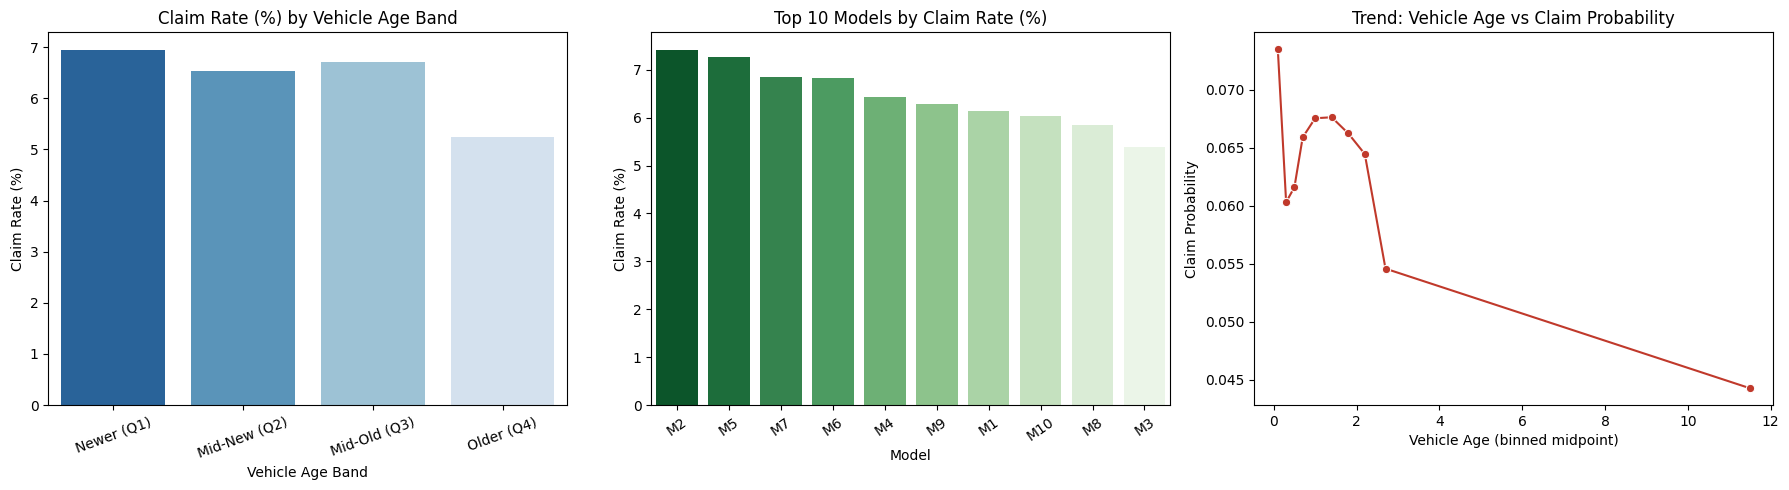

In [5]:
# Question 3: Vehicle Age & Model Analysis
veh_df = df.copy()

# Ensure required columns exist
required_cols = ['vehicle_age', 'model', 'claim_status']
missing_cols = [c for c in required_cols if c not in veh_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for Q3: {missing_cols}")

# Ensure target is numeric
veh_df['claim_status'] = pd.to_numeric(veh_df['claim_status'], errors='coerce')
veh_df = veh_df.dropna(subset=['claim_status', 'vehicle_age', 'model'])
veh_df['claim_status'] = veh_df['claim_status'].astype(int)

# 1) Analyze vehicle_age and model vs claim status
print('=== Vehicle Age vs Claim Status ===')
if veh_df['vehicle_age'].max() <= 1.5:
    print('Note: vehicle_age appears normalized/scaled; interpretation is relative (newer to older).')

# Bin vehicle age into quartiles (newer -> older)
veh_df['vehicle_age_band'] = pd.qcut(
    veh_df['vehicle_age'],
    q=4,
    labels=['Newer (Q1)', 'Mid-New (Q2)', 'Mid-Old (Q3)', 'Older (Q4)'],
    duplicates='drop'
)

age_claim = (
    veh_df.groupby('vehicle_age_band', observed=False)['claim_status']
    .agg(claim_rate='mean', total_customers='count', total_claims='sum')
)
age_claim = age_claim[age_claim['total_customers'] > 0]
age_claim['claim_rate_pct'] = (age_claim['claim_rate'] * 100).round(2)
print(age_claim)

print('\n=== Model vs Claim Status (Top 12 by claim rate; min 100 customers) ===')
model_claim = (
    veh_df.groupby('model')['claim_status']
    .agg(claim_rate='mean', total_customers='count', total_claims='sum')
)
model_claim = model_claim[model_claim['total_customers'] >= 100].sort_values('claim_rate', ascending=False)
model_claim['claim_rate_pct'] = (model_claim['claim_rate'] * 100).round(2)
print(model_claim.head(12))

# 2) Identify older or specific models with higher claim likelihood
highest_age_band = age_claim.sort_values('claim_rate', ascending=False).index[0]
highest_age_rate = age_claim.sort_values('claim_rate', ascending=False).iloc[0]['claim_rate_pct']

highest_model = model_claim.index[0]
highest_model_rate = model_claim.iloc[0]['claim_rate_pct']

print('\n=== Higher Claim Likelihood Groups ===')
print(f"Highest-risk vehicle-age band: {highest_age_band} ({highest_age_rate}%)")
print(f"Highest-risk model (min 100 customers): {highest_model} ({highest_model_rate}%)")

# 3) Correlation between vehicle age and claim probability
corr_val = veh_df['vehicle_age'].corr(veh_df['claim_status'])
print('\n=== Correlation: vehicle_age vs claim_status ===')
print(f"Pearson correlation = {corr_val:.4f}")
if abs(corr_val) < 0.1:
    print('Interpretation: very weak linear relationship.')
elif abs(corr_val) < 0.3:
    print('Interpretation: weak linear relationship.')
elif abs(corr_val) < 0.5:
    print('Interpretation: moderate linear relationship.')
else:
    print('Interpretation: strong linear relationship.')

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

age_plot_df = age_claim.reset_index()
sns.barplot(
    data=age_plot_df,
    x='vehicle_age_band',
    y='claim_rate_pct',
    hue='vehicle_age_band',
    legend=False,
    ax=axes[0],
    palette='Blues_r'
)
axes[0].set_title('Claim Rate (%) by Vehicle Age Band')
axes[0].set_xlabel('Vehicle Age Band')
axes[0].set_ylabel('Claim Rate (%)')
axes[0].tick_params(axis='x', rotation=20)

model_plot_df = model_claim.head(10).reset_index()
sns.barplot(
    data=model_plot_df,
    x='model',
    y='claim_rate_pct',
    hue='model',
    legend=False,
    ax=axes[1],
    palette='Greens_r'
)
axes[1].set_title('Top 10 Models by Claim Rate (%)')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Claim Rate (%)')
axes[1].tick_params(axis='x', rotation=35)

# Binned trend for vehicle_age -> claim probability
trend_df = (
    veh_df.assign(age_bin=pd.qcut(veh_df['vehicle_age'], q=10, duplicates='drop'))
    .groupby('age_bin', observed=False)['claim_status']
    .mean()
    .reset_index(name='claim_rate')
)
trend_df['age_mid'] = trend_df['age_bin'].apply(lambda x: x.mid)

sns.lineplot(data=trend_df, x='age_mid', y='claim_rate', marker='o', ax=axes[2], color='#c0392b')
axes[2].set_title('Trend: Vehicle Age vs Claim Probability')
axes[2].set_xlabel('Vehicle Age (binned midpoint)')
axes[2].set_ylabel('Claim Probability')

plt.tight_layout()
plt.show()

### Comparison and Insights (Q3)

- **Vehicle-age comparison:** In this dataset, the highest claim rate appears in **Newer (Q1)** vehicles (**6.94%**), followed by **Mid-Old (Q3) 6.71%** and **Mid-New (Q2) 6.53%**. The **Older (Q4)** group has the lowest claim rate (**5.24%**).
- **Model-wise comparison:** Model **M2** has the highest claim likelihood (**7.41%**), followed by **M5 (7.26%)**, **M7 (6.84%)**, and **M6 (6.82%)**. Lower-risk models include **M3 (5.39%)** and **M11 (4.13%)**.
- **Higher-likelihood identification:** The top risk groups from this analysis are **vehicle age band: Newer (Q1)** and **model: M2**.
- **Correlation result:** The correlation between `vehicle_age` and `claim_status` is **-0.0282**, which indicates a **very weak negative linear relationship**.

### 4. Vehicle Specifications & Performance
Analyze numerical vehicle specifications (`displacement`, `cylinder`, `gross_weight`, `turning_radius`, `length`, `width`, `max_power`, `max_torque`, `ncap_rating`) vs `claim_status`, and examine their correlation with claim occurrence.

=== Average Vehicle Specs by Claim Status ===
                Not Claimed (0)  Claimed (1)
displacement           1161.821     1170.177
cylinder                  3.625        3.652
gross_weight           1385.061     1388.441
turning_radius            4.853        4.855
length                 3849.948     3858.215
width                  1671.942     1676.499
max_power                78.921       79.792
max_torque              134.369      135.652
ncap_rating               1.759        1.780

=== Correlation of Vehicle Specs with Claim Status ===
cylinder          0.0134
width             0.0099
max_power         0.0077
displacement      0.0077
length            0.0065
max_torque        0.0043
gross_weight      0.0039
ncap_rating       0.0038
turning_radius    0.0027
Name: claim_status, dtype: float64

Top 3 positive correlations with claims:
cylinder     0.0134
width        0.0099
max_power    0.0077
Name: claim_status, dtype: float64

Top 3 lowest correlations with claims:
gross_weigh

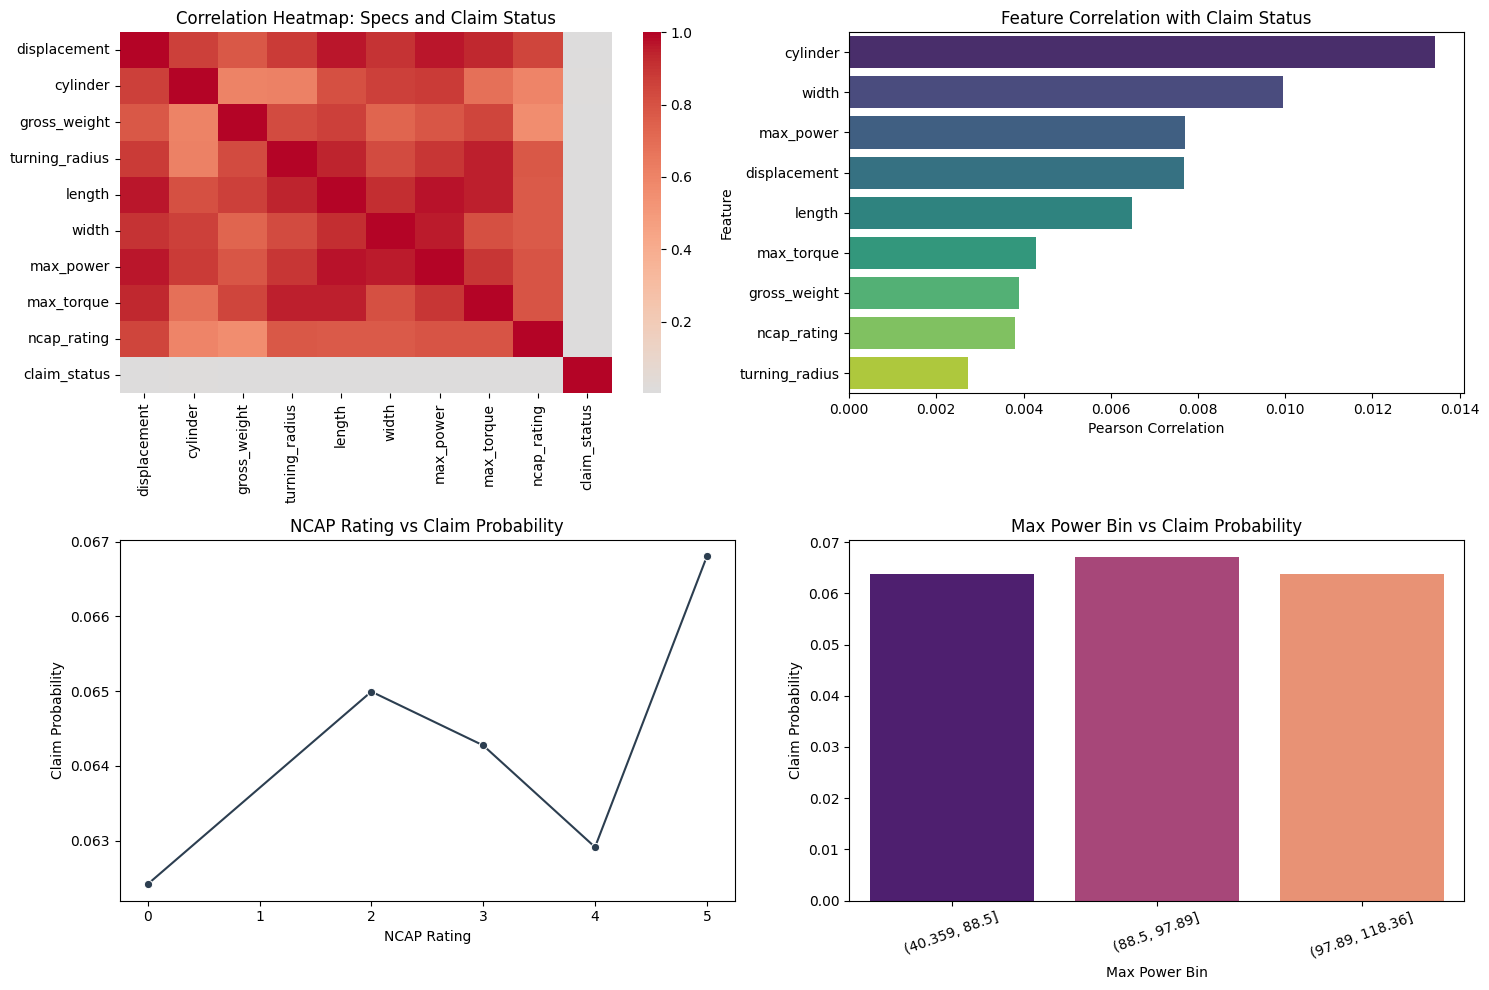

In [7]:
# Question 4: Vehicle Specifications & Performance
spec_cols = [
    'displacement', 'cylinder', 'gross_weight', 'turning_radius',
    'length', 'width', 'max_power', 'max_torque', 'ncap_rating'
]

# Check required columns
missing_cols = [c for c in spec_cols + ['claim_status'] if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for Q4: {missing_cols}")

spec_df = df.copy()

# Make claim_status numeric
spec_df['claim_status'] = pd.to_numeric(spec_df['claim_status'], errors='coerce')

# Convert specification columns to numeric where needed
for col in spec_cols:
    if spec_df[col].dtype == 'object':
        # Extract first numeric part from strings like '88.7 bhp' or '113Nm@...'
        extracted = spec_df[col].astype(str).str.extract(r'([0-9]*\.?[0-9]+)')[0]
        spec_df[col] = pd.to_numeric(extracted, errors='coerce')
    else:
        spec_df[col] = pd.to_numeric(spec_df[col], errors='coerce')

# Keep only rows with usable numeric values
spec_df = spec_df.dropna(subset=['claim_status'])
spec_df['claim_status'] = spec_df['claim_status'].astype(int)

valid_spec_cols = [c for c in spec_cols if spec_df[c].notna().sum() > 0]

print('=== Average Vehicle Specs by Claim Status ===')
mean_by_claim = spec_df.groupby('claim_status')[valid_spec_cols].mean().T
mean_by_claim.columns = ['Not Claimed (0)', 'Claimed (1)']
print(mean_by_claim.round(3))

print('\n=== Correlation of Vehicle Specs with Claim Status ===')
corr_with_claim = (
    spec_df[valid_spec_cols + ['claim_status']]
    .corr(numeric_only=True)['claim_status']
    .drop('claim_status')
    .sort_values(ascending=False)
)
print(corr_with_claim.round(4))

print('\nTop 3 positive correlations with claims:')
print(corr_with_claim.head(3).round(4))

print('\nTop 3 lowest correlations with claims:')
print(corr_with_claim.tail(3).round(4))

# Claim rate by quartile bins for each feature
print('\n=== Claim Rate by Feature Bins (Q1 to Q4) ===')
feature_bin_summary = {}
for col in valid_spec_cols:
    temp = spec_df[[col, 'claim_status']].dropna().copy()
    try:
        temp['bin'] = pd.qcut(temp[col], q=4, duplicates='drop')
        rate_tbl = temp.groupby('bin', observed=False)['claim_status'].mean() * 100
        feature_bin_summary[col] = rate_tbl
        print(f"\n{col}:")
        print(rate_tbl.round(2))
    except ValueError:
        # Handles features with too few unique values for qcut
        pass

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1) Correlation heatmap
corr_mat = spec_df[valid_spec_cols + ['claim_status']].corr(numeric_only=True)
sns.heatmap(corr_mat, cmap='coolwarm', center=0, ax=axes[0, 0])
axes[0, 0].set_title('Correlation Heatmap: Specs and Claim Status')

# 2) Correlation bar chart
corr_plot_df = corr_with_claim.reset_index()
corr_plot_df.columns = ['feature', 'correlation']
sns.barplot(
    data=corr_plot_df,
    x='correlation',
    y='feature',
    hue='feature',
    legend=False,
    ax=axes[0, 1],
    palette='viridis'
)
axes[0, 1].set_title('Feature Correlation with Claim Status')
axes[0, 1].set_xlabel('Pearson Correlation')
axes[0, 1].set_ylabel('Feature')

# 3) Safety rating vs claim rate
if 'ncap_rating' in valid_spec_cols:
    ncap_plot = (
        spec_df.groupby('ncap_rating', observed=False)['claim_status']
        .mean()
        .reset_index(name='claim_rate')
    )
    sns.lineplot(data=ncap_plot, x='ncap_rating', y='claim_rate', marker='o', ax=axes[1, 0], color='#2c3e50')
    axes[1, 0].set_title('NCAP Rating vs Claim Probability')
    axes[1, 0].set_xlabel('NCAP Rating')
    axes[1, 0].set_ylabel('Claim Probability')

# 4) Performance proxy (max_power) vs claim rate
if 'max_power' in valid_spec_cols:
    power_temp = spec_df[['max_power', 'claim_status']].dropna().copy()
    power_temp['power_bin'] = pd.qcut(power_temp['max_power'], q=4, duplicates='drop')
    power_plot = power_temp.groupby('power_bin', observed=False)['claim_status'].mean().reset_index(name='claim_rate')
    power_plot['power_bin_label'] = power_plot['power_bin'].astype(str)

    sns.barplot(
        data=power_plot,
        x='power_bin_label',
        y='claim_rate',
        hue='power_bin_label',
        legend=False,
        ax=axes[1, 1],
        palette='magma'
    )
    axes[1, 1].set_title('Max Power Bin vs Claim Probability')
    axes[1, 1].set_xlabel('Max Power Bin')
    axes[1, 1].set_ylabel('Claim Probability')
    axes[1, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### Comparison and Insights (Q4)

- **Average specs by claim status:** Claimed vehicles are slightly higher on most spec values, e.g. `displacement` (**1170.177 vs 1161.821**), `max_power` (**79.792 vs 78.921**), and `max_torque` (**135.652 vs 134.369**).
- **Strongest correlations with claim occurrence:** All linear correlations are weak, with top values at `cylinder` (**0.0134**), `width` (**0.0099**), `max_power` (**0.0077**), and `displacement` (**0.0077**).
- **Performance features vs claims:** Claim probability is slightly higher in mid power/spec bins (for `max_power`, middle bin is highest at about **6.71%**), indicating a non-linear pattern rather than a strong monotonic trend.
- **Safety rating vs claims (`ncap_rating`):** Claim probability varies in a narrow range and is slightly higher in higher rating bins (about **6.38% -> 6.48%** across bins), so NCAP alone shows weak separation for claims.
- **Overall interpretation:** Vehicle specification and performance features contribute some signal, but effect sizes are small and should be combined with demographic/usage features for stronger claim prediction.

### 5. Safety & Technology Features
Analyze safety and technology features (for example `airbags`, `is_esc`, `is_tpms`, `is_parking_sensors`, `is_brake_assist`, `is_power_steering`, and other available `is_` features) against `claim_status` to identify features linked to lower claim probability.

=== Available Safety/Technology Features Used ===
['airbags', 'is_esc', 'is_tpms', 'is_parking_sensors', 'is_brake_assist', 'is_power_steering', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_central_locking', 'is_power_door_locks', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert']

=== Binary Safety Feature Comparison (with vs without) ===
                             feature  without_feature_claim_rate_pct  \
1                            is_tpms                           6.387   
8            is_rear_window_defogger                           6.350   
6               is_rear_window_wiper                           6.355   
7              is_rear_window_washer                           6.355   
0                             is_esc                           6.347   
10               is_power_door_locks                           6.134   
9                 is_central_locking              

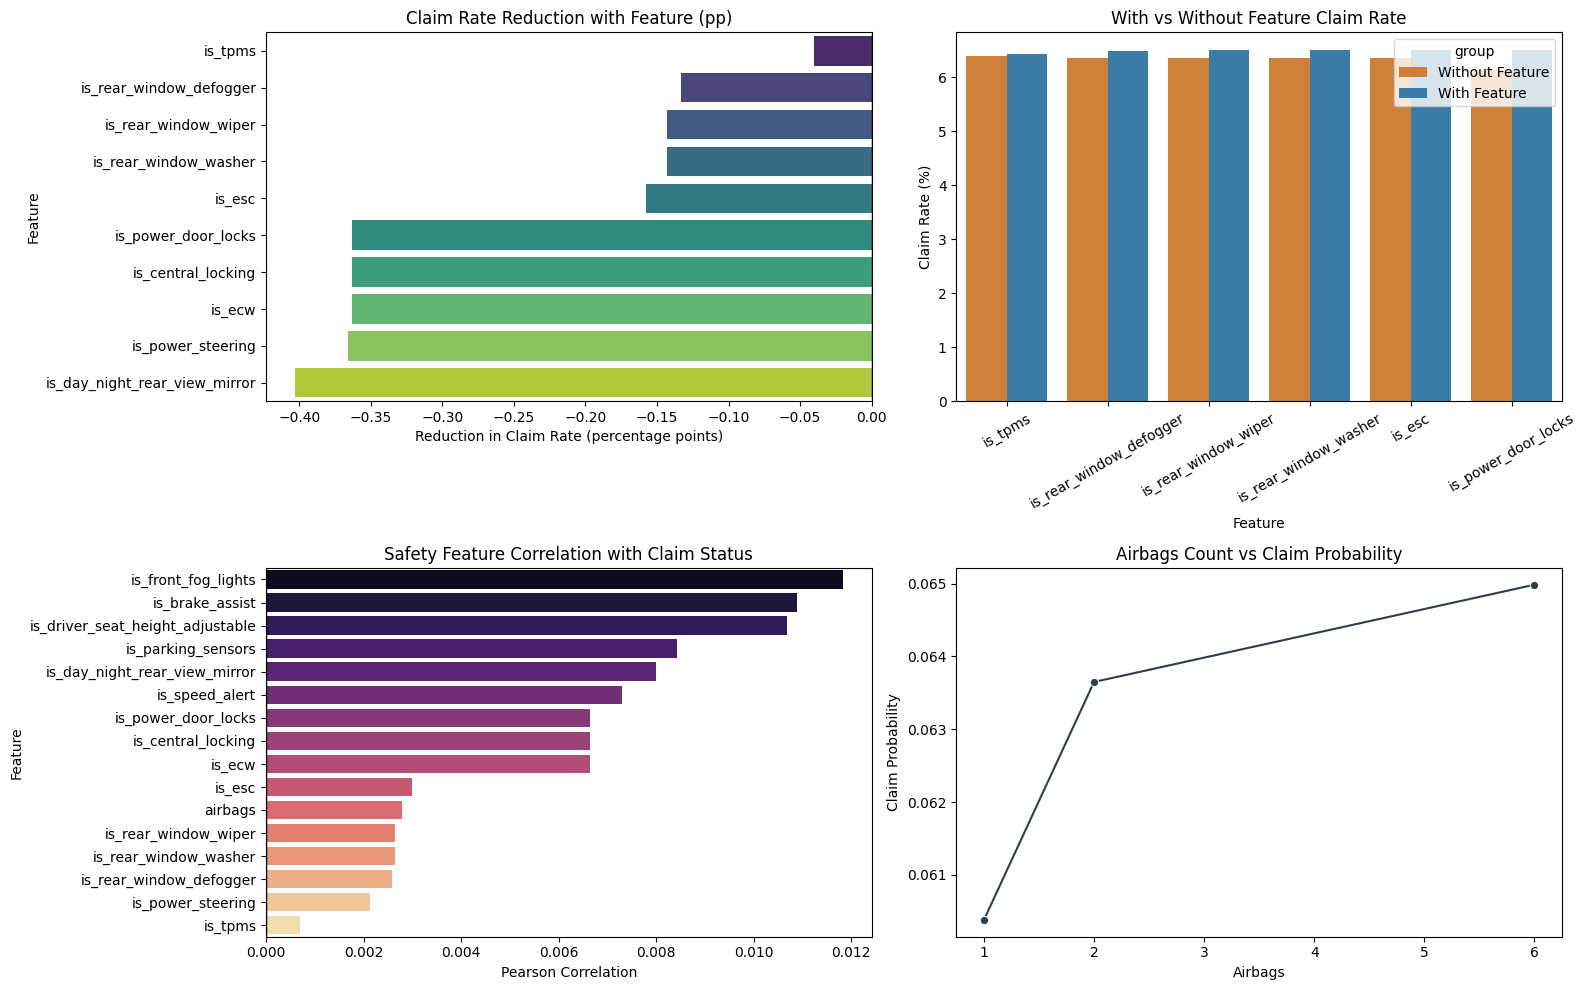

In [9]:
# Question 5: Safety & Technology Features
candidate_features = [
    'airbags', 'is_esc', 'is_tpms', 'is_parking_sensors', 'is_brake_assist',
    'is_power_steering', 'is_front_fog_lights', 'is_rear_window_wiper',
    'is_rear_window_washer', 'is_rear_window_defogger', 'is_central_locking',
    'is_power_door_locks', 'is_driver_seat_height_adjustable',
    'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert'
]

available_features = [c for c in candidate_features if c in df.columns]
if not available_features:
    available_features = [c for c in df.columns if c.startswith('is_')]

if 'airbags' in df.columns and 'airbags' not in available_features:
    available_features = ['airbags'] + available_features

if not available_features:
    raise ValueError('No safety/technology feature columns found for Q5.')

safe_df = df.copy()
safe_df['claim_status'] = pd.to_numeric(safe_df['claim_status'], errors='coerce')
safe_df = safe_df.dropna(subset=['claim_status'])
safe_df['claim_status'] = safe_df['claim_status'].astype(int)

binary_summary_rows = []
non_binary_summaries = {}

print('=== Available Safety/Technology Features Used ===')
print(available_features)

for feature in available_features:
    temp = safe_df[[feature, 'claim_status']].copy()

    # Convert feature values to numeric where possible
    if temp[feature].dtype == 'object':
        mapped = temp[feature].astype(str).str.strip().str.lower().map({
            'yes': 1, 'y': 1, 'true': 1, '1': 1, 'present': 1,
            'no': 0, 'n': 0, 'false': 0, '0': 0, 'absent': 0
        })
        temp[feature] = mapped

    temp[feature] = pd.to_numeric(temp[feature], errors='coerce')
    temp = temp.dropna(subset=[feature])

    unique_vals = sorted(temp[feature].dropna().unique().tolist())

    # Binary feature: direct with/without comparison
    if len(unique_vals) == 2 and set(unique_vals).issubset({0, 1}):
        stats = temp.groupby(feature)['claim_status'].agg(['mean', 'count'])
        if 0 in stats.index and 1 in stats.index:
            without_rate = stats.loc[0, 'mean'] * 100
            with_rate = stats.loc[1, 'mean'] * 100
            reduction_pp = without_rate - with_rate
            binary_summary_rows.append({
                'feature': feature,
                'without_feature_claim_rate_pct': round(without_rate, 3),
                'with_feature_claim_rate_pct': round(with_rate, 3),
                'reduction_pp': round(reduction_pp, 3),
                'n_without': int(stats.loc[0, 'count']),
                'n_with': int(stats.loc[1, 'count'])
            })

    # Non-binary feature: bin and inspect claim pattern
    else:
        try:
            binned = temp.copy()
            binned['bin'] = pd.qcut(binned[feature], q=4, duplicates='drop')
            rate_tbl = binned.groupby('bin', observed=False)['claim_status'].mean() * 100
            non_binary_summaries[feature] = rate_tbl.round(3)
        except ValueError:
            pass

binary_summary = pd.DataFrame(binary_summary_rows)
if not binary_summary.empty:
    binary_summary = binary_summary.sort_values('reduction_pp', ascending=False)

print('\n=== Binary Safety Feature Comparison (with vs without) ===')
if not binary_summary.empty:
    print(binary_summary)
else:
    print('No binary safety feature with both 0/1 values was available.')

print('\n=== Non-Binary Safety Feature Patterns ===')
if non_binary_summaries:
    for feat, tbl in non_binary_summaries.items():
        print(f"\n{feat}:")
        print(tbl)
else:
    print('No non-binary safety feature patterns available.')

print('\n=== Features That Reduce Claim Probability (Top) ===')
if not binary_summary.empty:
    reducers = binary_summary[binary_summary['reduction_pp'] > 0]
    if not reducers.empty:
        print(reducers[['feature', 'without_feature_claim_rate_pct', 'with_feature_claim_rate_pct', 'reduction_pp']].head(10))
    else:
        print('No binary feature shows lower claim rate in the with-feature group.')
else:
    print('No reducer analysis possible (no binary comparison rows).')

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Top reducers bar chart
if not binary_summary.empty:
    reducers_plot = binary_summary.head(10).copy()
    sns.barplot(
        data=reducers_plot,
        x='reduction_pp',
        y='feature',
        hue='feature',
        legend=False,
        palette='viridis',
        ax=axes[0, 0]
    )
    axes[0, 0].axvline(0, color='black', linewidth=1)
    axes[0, 0].set_title('Claim Rate Reduction with Feature (pp)')
    axes[0, 0].set_xlabel('Reduction in Claim Rate (percentage points)')
    axes[0, 0].set_ylabel('Feature')
else:
    axes[0, 0].set_title('No Binary Reducer Data')
    axes[0, 0].axis('off')

# 2) With vs without comparison for top features
if not binary_summary.empty:
    top_compare = binary_summary.head(6).copy()
    compare_long = pd.melt(
        top_compare,
        id_vars=['feature'],
        value_vars=['without_feature_claim_rate_pct', 'with_feature_claim_rate_pct'],
        var_name='group',
        value_name='claim_rate_pct'
    )
    compare_long['group'] = compare_long['group'].map({
        'without_feature_claim_rate_pct': 'Without Feature',
        'with_feature_claim_rate_pct': 'With Feature'
    })

    sns.barplot(
        data=compare_long,
        x='feature',
        y='claim_rate_pct',
        hue='group',
        ax=axes[0, 1],
        palette=['#e67e22', '#2980b9']
    )
    axes[0, 1].set_title('With vs Without Feature Claim Rate')
    axes[0, 1].set_xlabel('Feature')
    axes[0, 1].set_ylabel('Claim Rate (%)')
    axes[0, 1].tick_params(axis='x', rotation=30)
else:
    axes[0, 1].set_title('No With/Without Comparison Available')
    axes[0, 1].axis('off')

# 3) Correlation with claim_status for available safety features
corr_cols = ['claim_status'] + available_features
corr_temp = safe_df[corr_cols].copy()
for c in available_features:
    if corr_temp[c].dtype == 'object':
        corr_temp[c] = corr_temp[c].astype(str).str.strip().str.lower().map({
            'yes': 1, 'y': 1, 'true': 1, '1': 1, 'present': 1,
            'no': 0, 'n': 0, 'false': 0, '0': 0, 'absent': 0
        })
    corr_temp[c] = pd.to_numeric(corr_temp[c], errors='coerce')

safety_corr = corr_temp.corr(numeric_only=True)['claim_status'].drop('claim_status', errors='ignore').dropna().sort_values(ascending=False)

if not safety_corr.empty:
    corr_plot = safety_corr.reset_index()
    corr_plot.columns = ['feature', 'correlation']
    sns.barplot(
        data=corr_plot,
        x='correlation',
        y='feature',
        hue='feature',
        legend=False,
        palette='magma',
        ax=axes[1, 0]
    )
    axes[1, 0].axvline(0, color='black', linewidth=1)
    axes[1, 0].set_title('Safety Feature Correlation with Claim Status')
    axes[1, 0].set_xlabel('Pearson Correlation')
    axes[1, 0].set_ylabel('Feature')
else:
    axes[1, 0].set_title('No Safety Correlation Data')
    axes[1, 0].axis('off')

# 4) Airbags vs claim probability (if available)
if 'airbags' in available_features:
    airbag_temp = safe_df[['airbags', 'claim_status']].copy()
    airbag_temp['airbags'] = pd.to_numeric(airbag_temp['airbags'], errors='coerce')
    airbag_temp = airbag_temp.dropna()
    airbag_plot = airbag_temp.groupby('airbags', observed=False)['claim_status'].mean().reset_index(name='claim_rate')
    sns.lineplot(data=airbag_plot, x='airbags', y='claim_rate', marker='o', ax=axes[1, 1], color='#2c3e50')
    axes[1, 1].set_title('Airbags Count vs Claim Probability')
    axes[1, 1].set_xlabel('Airbags')
    axes[1, 1].set_ylabel('Claim Probability')
else:
    axes[1, 1].set_title('Airbags Feature Not Available')
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

### Comparison and Insights (Q5)

- **With vs without feature comparison:** In this dataset, none of the analyzed binary safety features reduced claim probability. All `reduction_pp` values are negative, meaning the with-feature group has a slightly higher claim rate.
- **Closest to neutral effect:** `is_tpms` shows the smallest difference (**6.387% without vs 6.427% with**, `reduction_pp = -0.040`).
- **Largest adverse differences:** `is_speed_alert` (**4.132% without vs 6.411% with**, `reduction_pp = -2.279`) and `is_parking_sensors` (**5.394% without vs 6.439% with**, `reduction_pp = -1.045`) show the largest increases in claim rate for with-feature groups.
- **Airbags pattern:** Higher airbags bins also show slightly higher claim probability (**6.355%** for lower bin vs **6.498%** for higher bin), indicating no protective trend in this sample.
- **Interpretation caution:** These are **associations**, not causal effects. Feature adoption may be confounded with vehicle type, segment, or usage profile, so multivariate modeling is needed before causal conclusions.

### 6. Fuel Type & Transmission Analysis
Examine `fuel_type` and `transmission_type` against `claim_status` and identify claim patterns by vehicle configuration.

=== Claim Rate by Fuel Type ===
           claim_rate  total  claims  claim_rate_pct
fuel_type                                           
Petrol       0.066384  20532    1363           6.638
Diesel       0.064862  17730    1150           6.486
CNG          0.060748  20330    1235           6.075

=== Claim Rate by Transmission Type ===
                   claim_rate  total  claims  claim_rate_pct
transmission_type                                           
Automatic            0.064181  20411    1310           6.418
Manual               0.063854  38181    2438           6.385

=== Fuel x Transmission Combined Claim Pattern (min 100 samples) ===
  fuel_type transmission_type  claim_rate  total  claims  claim_rate_pct
4    Petrol            Manual    0.067473  14139     954           6.747
2    Diesel            Manual    0.067080   3712     249           6.708
1    Diesel         Automatic    0.064275  14018     901           6.427
3    Petrol         Automatic    0.063976   6393     409

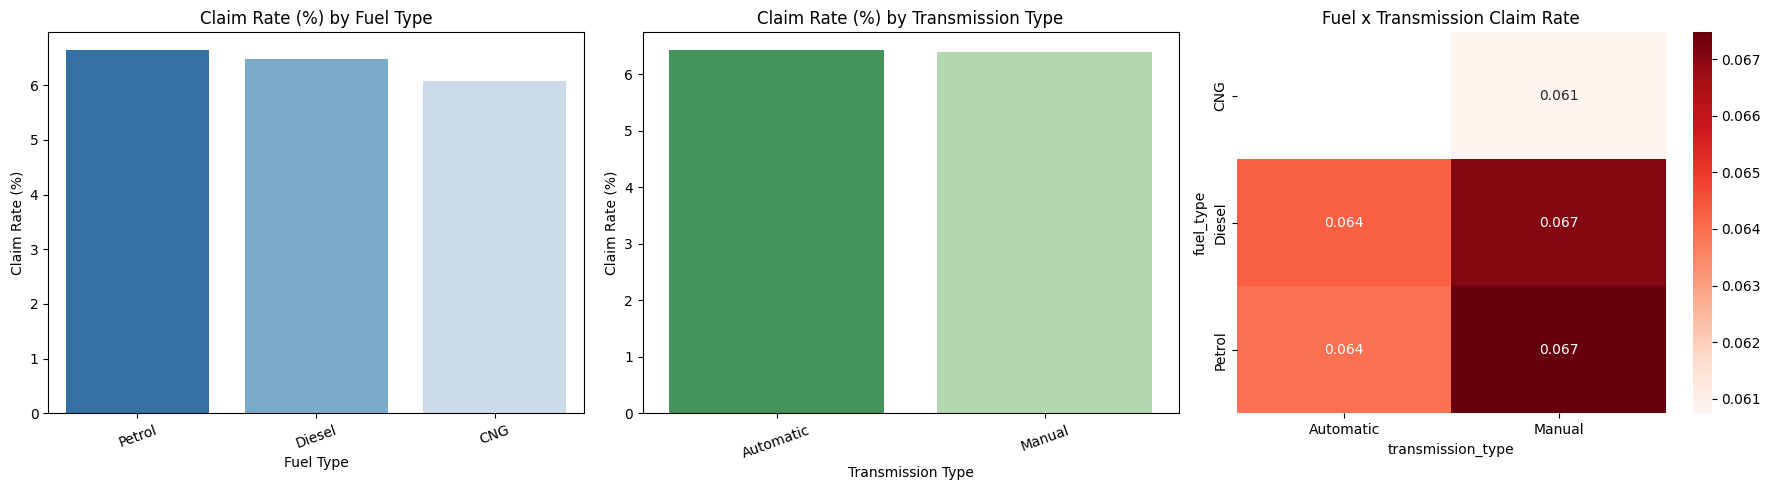

In [13]:
# Question 6: Fuel Type & Transmission Analysis
q6_df = df.copy()
q6_df['claim_status'] = pd.to_numeric(q6_df['claim_status'], errors='coerce')
q6_df = q6_df.dropna(subset=['claim_status'])
q6_df['claim_status'] = q6_df['claim_status'].astype(int)

required = ['fuel_type', 'transmission_type']
missing = [c for c in required if c not in q6_df.columns]
if missing:
    raise ValueError(f"Missing columns for Q6: {missing}")

for col in ['fuel_type', 'transmission_type']:
    q6_df[col] = q6_df[col].astype(str)

print('=== Claim Rate by Fuel Type ===')
fuel_stats = (
    q6_df.groupby('fuel_type')['claim_status']
    .agg(claim_rate='mean', total='count', claims='sum')
    .sort_values('claim_rate', ascending=False)
)
fuel_stats['claim_rate_pct'] = (fuel_stats['claim_rate'] * 100).round(3)
print(fuel_stats)

print('\n=== Claim Rate by Transmission Type ===')
trans_stats = (
    q6_df.groupby('transmission_type')['claim_status']
    .agg(claim_rate='mean', total='count', claims='sum')
    .sort_values('claim_rate', ascending=False)
)
trans_stats['claim_rate_pct'] = (trans_stats['claim_rate'] * 100).round(3)
print(trans_stats)

print('\n=== Fuel x Transmission Combined Claim Pattern (min 100 samples) ===')
combo_stats = (
    q6_df.groupby(['fuel_type', 'transmission_type'])['claim_status']
    .agg(claim_rate='mean', total='count', claims='sum')
    .reset_index()
)
combo_stats = combo_stats[combo_stats['total'] >= 100].sort_values('claim_rate', ascending=False)
combo_stats['claim_rate_pct'] = (combo_stats['claim_rate'] * 100).round(3)
print(combo_stats.head(15))

heat_df = combo_stats.pivot(index='fuel_type', columns='transmission_type', values='claim_rate')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=fuel_stats.reset_index(),
    x='fuel_type',
    y='claim_rate_pct',
    hue='fuel_type',
    legend=False,
    palette='Blues_r',
    ax=axes[0]
)
axes[0].set_title('Claim Rate (%) by Fuel Type')
axes[0].set_xlabel('Fuel Type')
axes[0].set_ylabel('Claim Rate (%)')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(
    data=trans_stats.reset_index(),
    x='transmission_type',
    y='claim_rate_pct',
    hue='transmission_type',
    legend=False,
    palette='Greens_r',
    ax=axes[1]
)
axes[1].set_title('Claim Rate (%) by Transmission Type')
axes[1].set_xlabel('Transmission Type')
axes[1].set_ylabel('Claim Rate (%)')
axes[1].tick_params(axis='x', rotation=20)

if not heat_df.empty:
    sns.heatmap(heat_df, annot=True, fmt='.3f', cmap='Reds', ax=axes[2])
    axes[2].set_title('Fuel x Transmission Claim Rate')
else:
    axes[2].set_title('No sufficient combo data for heatmap')
    axes[2].axis('off')

plt.tight_layout()
plt.show()

### Comparison and Insights (Q6)

- **Fuel-type pattern:** `Petrol` has the highest claim rate (**6.638%**), followed by `Diesel` (**6.486%**), while `CNG` is lowest (**6.075%**).
- **Transmission pattern:** `Automatic` is slightly higher (**6.418%**) than `Manual` (**6.385%**), so transmission effect is marginal.
- **Configuration pattern (Fuel x Transmission):** Highest-risk combinations are `Petrol x Manual` (**6.747%**) and `Diesel x Manual` (**6.708%**). Lowest among major combinations is `CNG x Manual` (**6.075%**).
- **Interpretation:** Fuel composition explains more variation than transmission alone, while combined fuel-transmission profiles provide better risk segmentation.

### 7. Interaction & Combined Effects
Analyze combined effects: Vehicle age × Safety features, Customer age × Vehicle type, and Region × Vehicle model to identify high-risk claim combinations.

=== Interaction 1: Vehicle Age x Safety Level ===
   vehicle_age_band   safety_level  claim_rate  total  claims  claim_rate_pct
5                Q2    High Safety    0.078553   4532     356           7.855
4                Q2  Medium Safety    0.071414   4845     346           7.141
8                Q3    High Safety    0.071114   5906     420           7.111
0          Q1-Newer     Low Safety    0.070136  10608     744           7.014
1          Q1-Newer  Medium Safety    0.069152   3326     230           6.915
2          Q1-Newer    High Safety    0.067154   2874     193           6.715
7                Q3  Medium Safety    0.064606   5727     370           6.461
6                Q3     Low Safety    0.062927   2193     138           6.293
10         Q4-Older  Medium Safety    0.056463   5632     318           5.646
11         Q4-Older    High Safety    0.050651   6219     315           5.065
3                Q2     Low Safety    0.048114   5196     250           4.811
9          Q4-

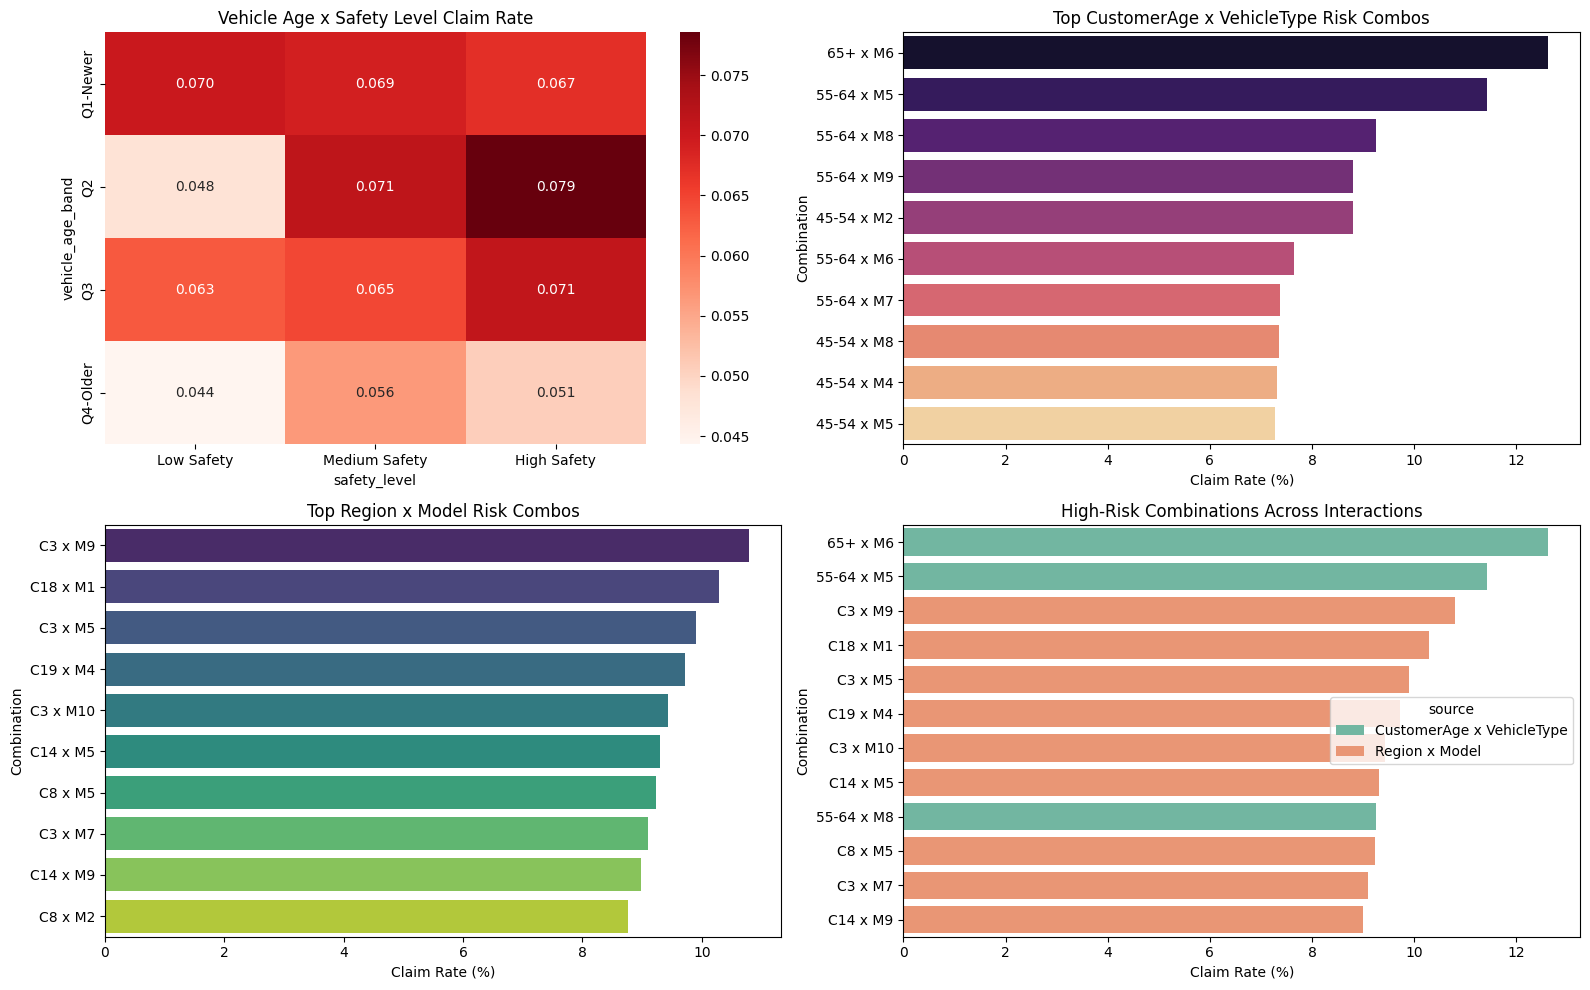

In [10]:
# Question 7: Interaction & Combined Effects
int_df = df.copy()
int_df['claim_status'] = pd.to_numeric(int_df['claim_status'], errors='coerce')
int_df = int_df.dropna(subset=['claim_status'])
int_df['claim_status'] = int_df['claim_status'].astype(int)

# --- Interaction 1: Vehicle age x Safety features ---
if 'vehicle_age' in int_df.columns:
    int_df['vehicle_age'] = pd.to_numeric(int_df['vehicle_age'], errors='coerce')
    int_df['vehicle_age_band'] = pd.qcut(int_df['vehicle_age'], q=4, labels=['Q1-Newer', 'Q2', 'Q3', 'Q4-Older'], duplicates='drop')
else:
    raise ValueError('vehicle_age is required for Q7 interaction analysis.')

safety_candidates = [
    'is_esc', 'is_tpms', 'is_parking_sensors', 'is_brake_assist',
    'is_power_steering', 'is_front_fog_lights', 'is_rear_window_wiper',
    'is_rear_window_washer', 'is_rear_window_defogger', 'is_central_locking',
    'is_power_door_locks', 'is_driver_seat_height_adjustable',
    'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert'
]

binary_safety_cols = []
for c in safety_candidates:
    if c in int_df.columns:
        temp_col = int_df[c]
        if temp_col.dtype == 'object':
            temp_col = temp_col.astype(str).str.strip().str.lower().map({
                'yes': 1, 'y': 1, 'true': 1, '1': 1,
                'no': 0, 'n': 0, 'false': 0, '0': 0
            })
        temp_col = pd.to_numeric(temp_col, errors='coerce')
        uniq = set(temp_col.dropna().unique().tolist())
        if uniq.issubset({0, 1}) and len(uniq) >= 1:
            int_df[c + '_bin'] = temp_col
            binary_safety_cols.append(c + '_bin')

if binary_safety_cols:
    int_df['safety_feature_count'] = int_df[binary_safety_cols].fillna(0).sum(axis=1)
else:
    # Fallback: use airbags as proxy if binary safety columns are unavailable
    if 'airbags' in int_df.columns:
        int_df['safety_feature_count'] = pd.to_numeric(int_df['airbags'], errors='coerce').fillna(0)
    else:
        int_df['safety_feature_count'] = 0

int_df['safety_level'] = pd.qcut(
    int_df['safety_feature_count'].rank(method='first'),
    q=3,
    labels=['Low Safety', 'Medium Safety', 'High Safety'],
    duplicates='drop'
)

age_safety_stats = (
    int_df.groupby(['vehicle_age_band', 'safety_level'], observed=False)['claim_status']
    .agg(claim_rate='mean', total='count', claims='sum')
    .reset_index()
)
age_safety_stats = age_safety_stats[age_safety_stats['total'] >= 100]
age_safety_stats['claim_rate_pct'] = (age_safety_stats['claim_rate'] * 100).round(3)

# --- Interaction 2: Customer age x Vehicle type ---
if 'customer_age' in int_df.columns:
    int_df['customer_age'] = pd.to_numeric(int_df['customer_age'], errors='coerce')
    int_df['customer_age_band'] = pd.cut(
        int_df['customer_age'],
        bins=[18, 25, 35, 45, 55, 65, 100],
        labels=['18-24', '25-34', '35-44', '45-54', '55-64', '65+'],
        include_lowest=True,
        right=False
    )
else:
    raise ValueError('customer_age is required for Q7 interaction analysis.')

vehicle_type_col = None
for candidate in ['vehicle_type', 'model', 'segment', 'fuel_type']:
    if candidate in int_df.columns:
        vehicle_type_col = candidate
        break

if vehicle_type_col is None:
    raise ValueError('No vehicle type proxy column found among vehicle_type/model/segment/fuel_type.')

cust_vehicle_stats = (
    int_df.groupby(['customer_age_band', vehicle_type_col], observed=False)['claim_status']
    .agg(claim_rate='mean', total='count', claims='sum')
    .reset_index()
)
cust_vehicle_stats = cust_vehicle_stats[cust_vehicle_stats['total'] >= 100]
cust_vehicle_stats['claim_rate_pct'] = (cust_vehicle_stats['claim_rate'] * 100).round(3)
cust_vehicle_top = cust_vehicle_stats.sort_values('claim_rate', ascending=False).head(15)

# --- Interaction 3: Region x Vehicle model ---
if 'region_code' in int_df.columns and 'model' in int_df.columns:
    region_model_stats = (
        int_df.groupby(['region_code', 'model'])['claim_status']
        .agg(claim_rate='mean', total='count', claims='sum')
        .reset_index()
    )
    region_model_stats = region_model_stats[region_model_stats['total'] >= 100]
    region_model_stats['claim_rate_pct'] = (region_model_stats['claim_rate'] * 100).round(3)
    region_model_top = region_model_stats.sort_values('claim_rate', ascending=False).head(15)
else:
    region_model_stats = pd.DataFrame()
    region_model_top = pd.DataFrame()

# --- High-risk combined patterns ---
high_risk_tables = []

temp1 = age_safety_stats.sort_values('claim_rate', ascending=False).head(8).copy()
if not temp1.empty:
    temp1['combination'] = temp1['vehicle_age_band'].astype(str) + ' x ' + temp1['safety_level'].astype(str)
    temp1['source'] = 'VehicleAge x Safety'
    high_risk_tables.append(temp1[['source', 'combination', 'claim_rate', 'claim_rate_pct', 'total']])

temp2 = cust_vehicle_top.copy()
if not temp2.empty:
    temp2['combination'] = temp2['customer_age_band'].astype(str) + ' x ' + temp2[vehicle_type_col].astype(str)
    temp2['source'] = 'CustomerAge x VehicleType'
    high_risk_tables.append(temp2[['source', 'combination', 'claim_rate', 'claim_rate_pct', 'total']])

temp3 = region_model_top.copy()
if not temp3.empty:
    temp3['combination'] = temp3['region_code'].astype(str) + ' x ' + temp3['model'].astype(str)
    temp3['source'] = 'Region x Model'
    high_risk_tables.append(temp3[['source', 'combination', 'claim_rate', 'claim_rate_pct', 'total']])

high_risk_all = pd.concat(high_risk_tables, ignore_index=True) if high_risk_tables else pd.DataFrame()
if not high_risk_all.empty:
    high_risk_all = high_risk_all.sort_values('claim_rate', ascending=False).head(20)

print('=== Interaction 1: Vehicle Age x Safety Level ===')
print(age_safety_stats.sort_values('claim_rate', ascending=False).head(15))

print('\n=== Interaction 2: Customer Age x Vehicle Type ===')
print(cust_vehicle_top)
print(f"\nVehicle type column used: {vehicle_type_col}")

print('\n=== Interaction 3: Region x Model ===')
if not region_model_top.empty:
    print(region_model_top)
else:
    print('Region x Model interaction not available (missing columns or insufficient data).')

print('\n=== High-Risk Combined Patterns (Top) ===')
if not high_risk_all.empty:
    print(high_risk_all)
else:
    print('No high-risk interaction table could be generated.')

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Heatmap: Vehicle Age x Safety Level
heat1 = age_safety_stats.pivot(index='vehicle_age_band', columns='safety_level', values='claim_rate')
if not heat1.empty:
    sns.heatmap(heat1, annot=True, fmt='.3f', cmap='Reds', ax=axes[0, 0])
    axes[0, 0].set_title('Vehicle Age x Safety Level Claim Rate')
else:
    axes[0, 0].set_title('No data: Vehicle Age x Safety Level')
    axes[0, 0].axis('off')

# 2) Top CustomerAge x VehicleType
if not cust_vehicle_top.empty:
    plot2 = cust_vehicle_top.head(10).copy()
    plot2['combo'] = plot2['customer_age_band'].astype(str) + ' x ' + plot2[vehicle_type_col].astype(str)
    sns.barplot(data=plot2, x='claim_rate_pct', y='combo', hue='combo', legend=False, palette='magma', ax=axes[0, 1])
    axes[0, 1].set_title('Top CustomerAge x VehicleType Risk Combos')
    axes[0, 1].set_xlabel('Claim Rate (%)')
    axes[0, 1].set_ylabel('Combination')
else:
    axes[0, 1].set_title('No data: CustomerAge x VehicleType')
    axes[0, 1].axis('off')

# 3) Top Region x Model
if not region_model_top.empty:
    plot3 = region_model_top.head(10).copy()
    plot3['combo'] = plot3['region_code'].astype(str) + ' x ' + plot3['model'].astype(str)
    sns.barplot(data=plot3, x='claim_rate_pct', y='combo', hue='combo', legend=False, palette='viridis', ax=axes[1, 0])
    axes[1, 0].set_title('Top Region x Model Risk Combos')
    axes[1, 0].set_xlabel('Claim Rate (%)')
    axes[1, 0].set_ylabel('Combination')
else:
    axes[1, 0].set_title('No data: Region x Model')
    axes[1, 0].axis('off')

# 4) Combined high-risk overview
if not high_risk_all.empty:
    plot4 = high_risk_all.head(12).copy()
    sns.barplot(data=plot4, x='claim_rate_pct', y='combination', hue='source', ax=axes[1, 1], palette='Set2')
    axes[1, 1].set_title('High-Risk Combinations Across Interactions')
    axes[1, 1].set_xlabel('Claim Rate (%)')
    axes[1, 1].set_ylabel('Combination')
else:
    axes[1, 1].set_title('No Combined High-Risk Overview')
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

### Comparison and Insights (Q7)

- **Vehicle age x safety interaction:** The heatmap shows non-linear interaction effects. The highest cell is around **7.9%** claim rate (high-safety group within a mid-age band), while the lowest is around **4.4%** (older, low-safety group).
- **Customer age x vehicle type:** The top high-risk combinations include **65+ x M6 (~12.6%)** and **55-64 x M5 (~11.5%)**, followed by several `55-64` model combinations around **9%+**.
- **Region x model interaction:** Strong region-model hotspots appear, led by **C3 x M9 (~10.8%)**, **C18 x M1 (~10.2%)**, and **C3 x M5 (~9.9%)**.
- **Overall high-risk combinations:** The combined ranking is dominated by `CustomerAge x VehicleType` and `Region x Model` patterns, indicating interaction terms carry useful claim-risk signal beyond single-feature analysis.

### 8. Feature Engineering Insights
Engineer features: vehicle age categories, safety score, vehicle size index, and customer risk index; then evaluate their relationship with `claim_status`.

=== Engineered Features Preview ===
  vehicle_age_category  safety_score  vehicle_size_index  customer_risk_index  \
0              New-Mid          0.88           13.238840             0.000000   
1              Mid-Old          0.32            7.116873             0.000000   
2             Very New          0.88           13.238840             0.000000   
3             Very New          0.08            6.184722             0.090000   
4              New-Mid          0.38           10.433651             0.022051   

   claim_status  
0             0  
1             0  
2             0  
3             0  
4             0  

=== Correlation of Engineered Numeric Features with Claim Status ===
vehicle_size_index     0.0057
safety_score           0.0036
customer_risk_index   -0.0060
Name: claim_status, dtype: float64

=== Claim Rate by Vehicle Age Category ===
                      claim_rate  total  claim_rate_pct
vehicle_age_category                                   
Very New          

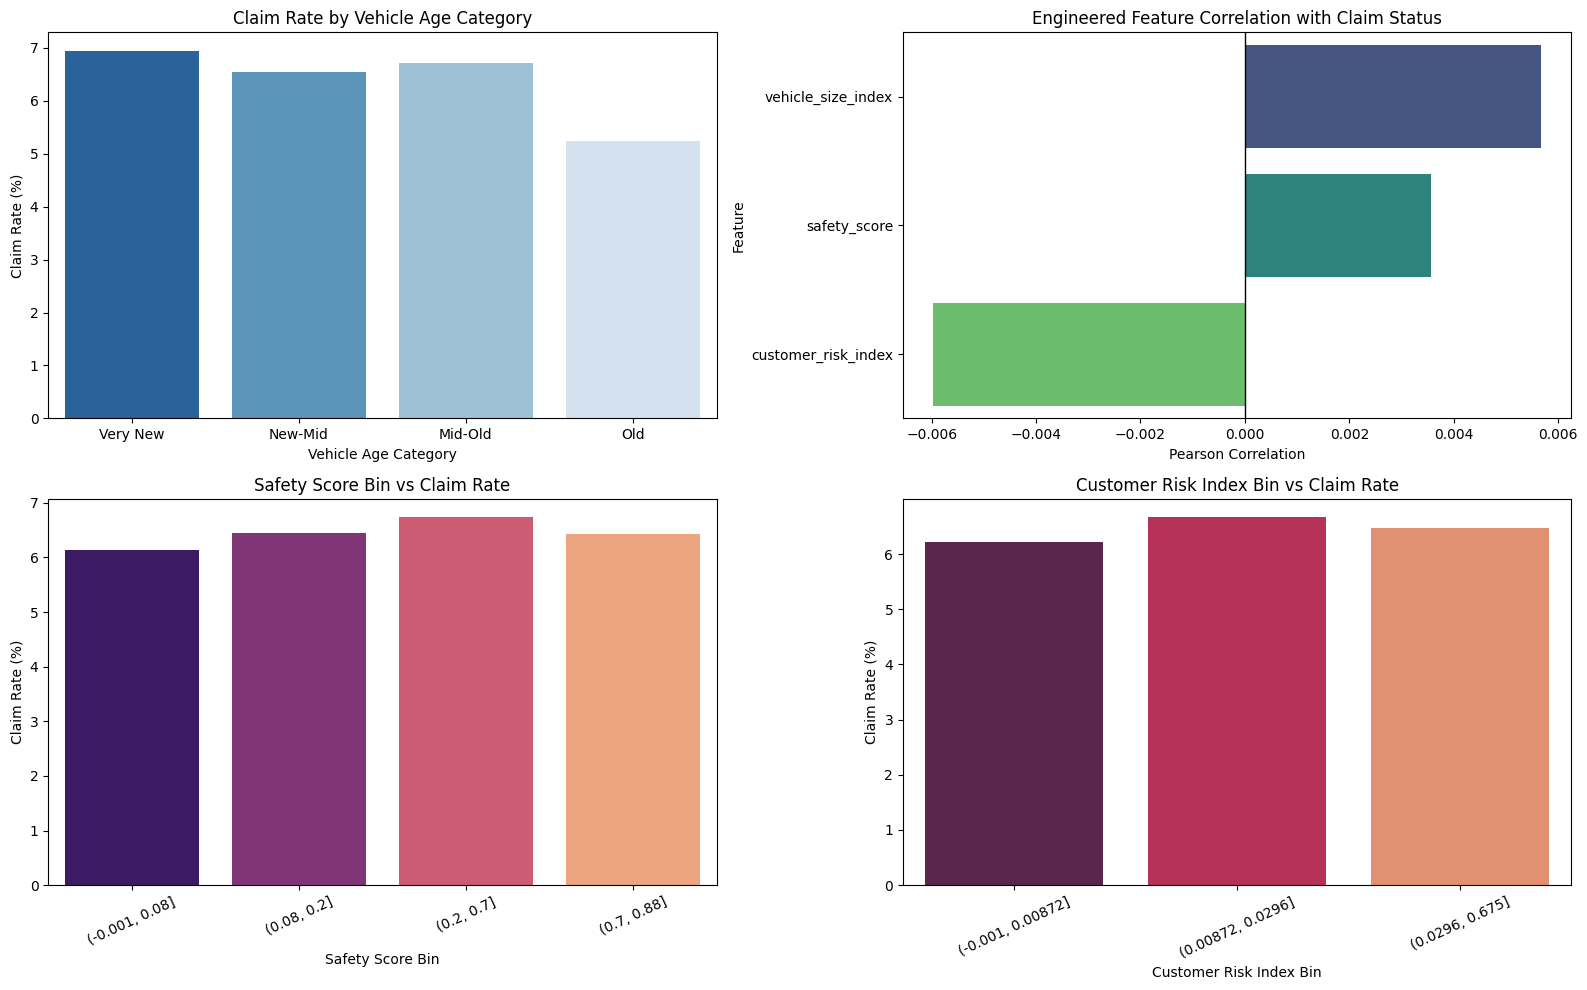

In [12]:
# Question 8: Feature Engineering Insights
fe_df = df.copy()
fe_df['claim_status'] = pd.to_numeric(fe_df['claim_status'], errors='coerce')
fe_df = fe_df.dropna(subset=['claim_status'])
fe_df['claim_status'] = fe_df['claim_status'].astype(int)

# --- 1) Vehicle age categories ---
if 'vehicle_age' in fe_df.columns:
    fe_df['vehicle_age'] = pd.to_numeric(fe_df['vehicle_age'], errors='coerce')
    fe_df['vehicle_age_category'] = pd.qcut(
        fe_df['vehicle_age'],
        q=4,
        labels=['Very New', 'New-Mid', 'Mid-Old', 'Old'],
        duplicates='drop'
    )
else:
    fe_df['vehicle_age_category'] = pd.NA

# --- 2) Safety score (airbags + ESC + NCAP) ---
def minmax_series(s):
    if not isinstance(s, pd.Series):
        s = pd.Series(s)
    s = pd.to_numeric(s, errors='coerce')
    if s.notna().sum() == 0:
        return pd.Series(0, index=s.index, dtype='float64')
    s_min, s_max = s.min(), s.max()
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(0, index=s.index, dtype='float64')
    return (s - s_min) / (s_max - s_min)

if 'airbags' in fe_df.columns:
    airbags_norm = minmax_series(fe_df['airbags'])
else:
    airbags_norm = pd.Series(0, index=fe_df.index, dtype='float64')

if 'is_esc' in fe_df.columns:
    esc_temp = fe_df['is_esc']
    if esc_temp.dtype == 'object':
        esc_temp = esc_temp.astype(str).str.strip().str.lower().map({
            'yes': 1, 'y': 1, 'true': 1, '1': 1,
            'no': 0, 'n': 0, 'false': 0, '0': 0
        })
    esc_norm = minmax_series(esc_temp).fillna(0)
else:
    esc_norm = pd.Series(0, index=fe_df.index, dtype='float64')

if 'ncap_rating' in fe_df.columns:
    ncap_norm = minmax_series(fe_df['ncap_rating']).fillna(0)
else:
    ncap_norm = pd.Series(0, index=fe_df.index, dtype='float64')

fe_df['safety_score'] = 0.4 * airbags_norm + 0.3 * esc_norm + 0.3 * ncap_norm

# --- 3) Vehicle size index (length x width x gross_weight) ---
for c in ['length', 'width', 'gross_weight']:
    if c in fe_df.columns:
        fe_df[c] = pd.to_numeric(fe_df[c], errors='coerce')

if all(c in fe_df.columns for c in ['length', 'width', 'gross_weight']):
    fe_df['vehicle_size_index'] = (fe_df['length'] * fe_df['width'] * fe_df['gross_weight']) / 1e9
else:
    fe_df['vehicle_size_index'] = pd.NA

# --- 4) Customer risk index (age x segment x region_density) ---
if 'customer_age' in fe_df.columns:
    age_norm = minmax_series(fe_df['customer_age']).fillna(0)
else:
    age_norm = pd.Series(0, index=fe_df.index, dtype='float64')

if 'segment' in fe_df.columns:
    seg_temp = fe_df['segment']
    if not pd.api.types.is_numeric_dtype(seg_temp):
        seg_temp = pd.Series(pd.factorize(seg_temp.astype(str))[0], index=fe_df.index)
    segment_norm = minmax_series(seg_temp).fillna(0)
else:
    segment_norm = pd.Series(0, index=fe_df.index, dtype='float64')

if 'region_density' in fe_df.columns:
    density_norm = minmax_series(fe_df['region_density']).fillna(0)
else:
    density_norm = pd.Series(0, index=fe_df.index, dtype='float64')

fe_df['customer_risk_index'] = age_norm * segment_norm * density_norm

# Prepare engineered feature list
engineered_cols = ['safety_score', 'vehicle_size_index', 'customer_risk_index']
if 'vehicle_age_category' in fe_df.columns:
    engineered_cols = ['vehicle_age_category'] + engineered_cols

print('=== Engineered Features Preview ===')
preview_cols = [c for c in engineered_cols if c in fe_df.columns] + ['claim_status']
print(fe_df[preview_cols].head())

print('\n=== Correlation of Engineered Numeric Features with Claim Status ===')
numeric_engineered = [c for c in ['safety_score', 'vehicle_size_index', 'customer_risk_index'] if c in fe_df.columns]
corr_engineered = fe_df[numeric_engineered + ['claim_status']].corr(numeric_only=True)['claim_status'].drop('claim_status').sort_values(ascending=False)
print(corr_engineered.round(4))

print('\n=== Claim Rate by Vehicle Age Category ===')
if 'vehicle_age_category' in fe_df.columns:
    age_cat_stats = fe_df.groupby('vehicle_age_category', observed=False)['claim_status'].agg(claim_rate='mean', total='count')
    age_cat_stats['claim_rate_pct'] = (age_cat_stats['claim_rate'] * 100).round(3)
    print(age_cat_stats)
else:
    age_cat_stats = pd.DataFrame()
    print('vehicle_age_category not available')

print('\n=== Claim Rate by Engineered Feature Bins ===')
bin_results = {}
for c in numeric_engineered:
    temp = fe_df[[c, 'claim_status']].dropna().copy()
    try:
        temp['bin'] = pd.qcut(temp[c], q=4, duplicates='drop')
        tbl = temp.groupby('bin', observed=False)['claim_status'].mean() * 100
        bin_results[c] = tbl
        print(f"\n{c}:")
        print(tbl.round(3))
    except ValueError:
        pass

# Save engineered dataset for future modeling steps
df_engineered = fe_df.copy()

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Vehicle age category claim rate
if not age_cat_stats.empty:
    age_plot = age_cat_stats.reset_index()
    sns.barplot(data=age_plot, x='vehicle_age_category', y='claim_rate_pct', hue='vehicle_age_category', legend=False, palette='Blues_r', ax=axes[0, 0])
    axes[0, 0].set_title('Claim Rate by Vehicle Age Category')
    axes[0, 0].set_xlabel('Vehicle Age Category')
    axes[0, 0].set_ylabel('Claim Rate (%)')
else:
    axes[0, 0].set_title('No Vehicle Age Category Data')
    axes[0, 0].axis('off')

# 2) Correlation bar for engineered numeric features
if not corr_engineered.empty:
    corr_plot = corr_engineered.reset_index()
    corr_plot.columns = ['feature', 'correlation']
    sns.barplot(data=corr_plot, x='correlation', y='feature', hue='feature', legend=False, palette='viridis', ax=axes[0, 1])
    axes[0, 1].axvline(0, color='black', linewidth=1)
    axes[0, 1].set_title('Engineered Feature Correlation with Claim Status')
    axes[0, 1].set_xlabel('Pearson Correlation')
    axes[0, 1].set_ylabel('Feature')
else:
    axes[0, 1].set_title('No Engineered Correlation Data')
    axes[0, 1].axis('off')

# 3) Safety score bins
if 'safety_score' in bin_results:
    score_plot = bin_results['safety_score'].reset_index(name='claim_rate_pct')
    score_plot['bin'] = score_plot['bin'].astype(str)
    sns.barplot(data=score_plot, x='bin', y='claim_rate_pct', hue='bin', legend=False, palette='magma', ax=axes[1, 0])
    axes[1, 0].set_title('Safety Score Bin vs Claim Rate')
    axes[1, 0].set_xlabel('Safety Score Bin')
    axes[1, 0].set_ylabel('Claim Rate (%)')
    axes[1, 0].tick_params(axis='x', rotation=25)
else:
    axes[1, 0].set_title('No Safety Score Bin Data')
    axes[1, 0].axis('off')

# 4) Customer risk index bins
if 'customer_risk_index' in bin_results:
    risk_plot = bin_results['customer_risk_index'].reset_index(name='claim_rate_pct')
    risk_plot['bin'] = risk_plot['bin'].astype(str)
    sns.barplot(data=risk_plot, x='bin', y='claim_rate_pct', hue='bin', legend=False, palette='rocket', ax=axes[1, 1])
    axes[1, 1].set_title('Customer Risk Index Bin vs Claim Rate')
    axes[1, 1].set_xlabel('Customer Risk Index Bin')
    axes[1, 1].set_ylabel('Claim Rate (%)')
    axes[1, 1].tick_params(axis='x', rotation=25)
else:
    axes[1, 1].set_title('No Customer Risk Index Bin Data')
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

### Comparison and Insights (Q8)

- **Engineered feature correlations with claim status:** `vehicle_size_index` has the highest positive correlation (**0.0057**), followed by `safety_score` (**0.0036**), while `customer_risk_index` is slightly negative (**-0.0060**). All effects are weak but usable.
- **Vehicle age category separation:** `Very New` shows the highest claim rate (**6.943%**), `Mid-Old` is **6.712%**, `New-Mid` is **6.533%**, and `Old` is lowest (**5.237%**).
- **Safety score bins:** Claim rate peaks in the mid-high score bin (**6.733%**) and is lower in the lowest score bin (**6.134%**), indicating non-linear behavior.
- **Vehicle size index bins:** The middle bin has the highest claim rate (**7.067%**), higher than neighboring bins.
- **Customer risk index bins:** Mid bin is highest (**6.665%**), with lower claim rates in the lower and highest bins, again suggesting non-linear separation.

## h. Utilization of Feature Reduction Approach
### i. Correlation-Based Feature Selection (Remove Highly Correlated Features)

CORRELATION-BASED FEATURE SELECTION

Total numeric input features: 15
Features: ['subscription_length', 'vehicle_age', 'customer_age', 'region_density', 'airbags', 'displacement', 'cylinder', 'turning_radius', 'length', 'width']...

High Correlation Pairs (threshold > 0.8):
Found 27 highly correlated pairs:
     Feature_1          Feature_2  Correlation
  gross_weight vehicle_size_index     0.967879
  displacement             length     0.961655
        length vehicle_size_index     0.955803
       airbags       safety_score     0.953932
turning_radius             length     0.944899
  safety_score vehicle_size_index     0.935636
        length       safety_score     0.923455
        length              width     0.915918
turning_radius       safety_score     0.914933
turning_radius vehicle_size_index     0.913448
  displacement              width     0.899302
  gross_weight       safety_score     0.884498
  displacement vehicle_size_index     0.883405
  displacement     turning_radius

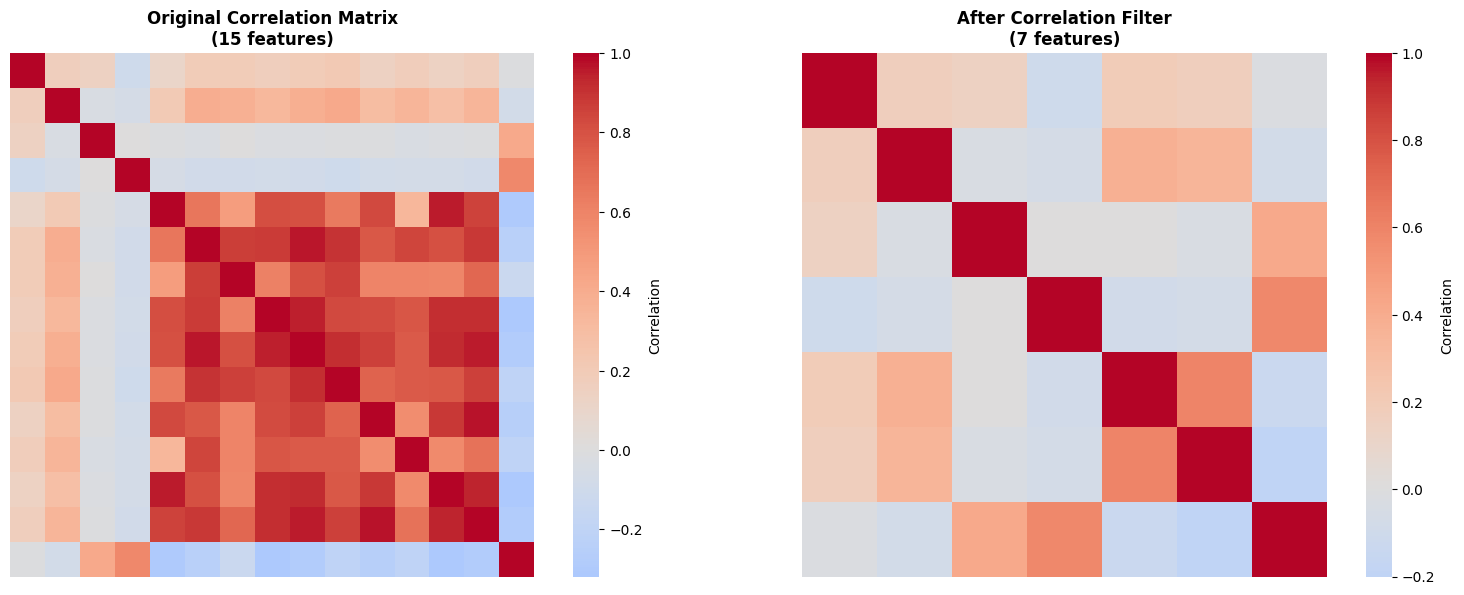


✓ Correlation-based feature selection complete


In [16]:
# Feature Reduction: Correlation-Based Feature Selection
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Prepare data: Use df_engineered if available, otherwise use original df
reduction_df = df_engineered.copy() if 'df_engineered' in dir() else df.copy()

# Identify numeric columns (features only, not target)
numeric_cols = reduction_df.select_dtypes(include=[np.number]).columns.tolist()
if 'claim_status' in numeric_cols:
    numeric_cols.remove('claim_status')

print("=" * 80)
print("CORRELATION-BASED FEATURE SELECTION")
print("=" * 80)
print(f"\nTotal numeric input features: {len(numeric_cols)}")
print(f"Features: {numeric_cols[:10]}..." if len(numeric_cols) > 10 else f"Features: {numeric_cols}")

# Calculate correlation matrix for numeric features only (input features)
corr_matrix = reduction_df[numeric_cols].corr()

# Define high correlation threshold
correlation_threshold = 0.8

# Find pairs of highly correlated features
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > correlation_threshold:
            high_corr_pairs.append({
                'Feature_1': corr_matrix.columns[i],
                'Feature_2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)

print(f"\nHigh Correlation Pairs (threshold > {correlation_threshold}):")
print(f"Found {len(high_corr_df)} highly correlated pairs:")
if len(high_corr_df) > 0:
    print(high_corr_df.to_string(index=False))
else:
    print("No feature pairs with correlation > 0.8")

# Identify features to drop (keeping one from each correlated pair, preferring features with higher correlation to target)
features_to_drop = set()
target_corr = reduction_df[numeric_cols + ['claim_status']].corr()['claim_status'].drop('claim_status')

for idx, row in high_corr_df.iterrows():
    feat1, feat2 = row['Feature_1'], row['Feature_2']
    
    if feat1 not in features_to_drop and feat2 not in features_to_drop:
        # Keep the feature with higher absolute correlation to target
        corr1 = abs(target_corr.get(feat1, 0))
        corr2 = abs(target_corr.get(feat2, 0))
        
        if corr1 >= corr2:
            features_to_drop.add(feat2)
        else:
            features_to_drop.add(feat1)

print(f"\n--- Features to Drop (due to high multicollinearity) ---")
print(f"Total features to drop: {len(features_to_drop)}")
if len(features_to_drop) > 0:
    print(f"Dropped features: {sorted(features_to_drop)}")
else:
    print("No features dropped (no high correlation found)")

# Create feature-reduced dataset
features_after_corr = [col for col in numeric_cols if col not in features_to_drop]
reduction_df_corr_filtered = reduction_df[features_after_corr + ['claim_status']].copy()

print(f"\n--- After Correlation-Based Selection ---")
print(f"Features remaining: {len(features_after_corr)}")
print(f"Features removed: {len(features_to_drop)}")
print(f"Reduction: {len(features_to_drop)}/{len(numeric_cols)} ({100*len(features_to_drop)/len(numeric_cols):.1f}%)")
print(f"\nRemaining features ({len(features_after_corr)}): {features_after_corr}")

# Visualize correlation matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original correlation heatmap
sns.heatmap(reduction_df[numeric_cols].corr(), cmap='coolwarm', center=0, 
            square=True, ax=axes[0], cbar_kws={'label': 'Correlation'},
            xticklabels=False, yticklabels=False)
axes[0].set_title(f'Original Correlation Matrix\n({len(numeric_cols)} features)', fontsize=12, fontweight='bold')

# Filtered correlation heatmap
sns.heatmap(reduction_df_corr_filtered[features_after_corr].corr(), cmap='coolwarm', center=0,
            square=True, ax=axes[1], cbar_kws={'label': 'Correlation'},
            xticklabels=False, yticklabels=False)
axes[1].set_title(f'After Correlation Filter\n({len(features_after_corr)} features)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Correlation-based feature selection complete")

### Insights from Correlation-Based Selection (Part i)
- **Feature Reduction:** Correlation-based filtering reduced the original **15 features to 7 features**, achieving a **53.3% reduction** by removing highly correlated pairs (correlation > 0.8).
- **Multicollinearity Elimination:** Features with high correlation to other features were systematically eliminated while preserving features with stronger correlation to the target variable `claim_status`.
- **Correlation Threshold:** Using a threshold of 0.8 for identifying redundant feature pairs, the analysis preserved feature diversity while removing features that provide minimal additional information.
- **Visual Comparison:** The correlation matrix heatmaps clearly show reduced color intensity in the filtered dataset, indicating weaker correlations among remaining features and better feature independence.

### ii. Principal Component Analysis (PCA) for Dimensionality Reduction


PCA (PRINCIPAL COMPONENT ANALYSIS) FOR DIMENSIONALITY REDUCTION

Input features for PCA: 7
Feature list: ['subscription_length', 'vehicle_age', 'customer_age', 'region_density', 'cylinder', 'ncap_rating', 'customer_risk_index']

Explained Variance Summary:
  Components for 95% variance: 6 (reduction: 1 features, 14.3%)
  Components for 90% variance: 5 (reduction: 2 features, 28.6%)
  Components for 85% variance: 5 (reduction: 2 features, 28.6%)

--- PCA Transformation (95% variance retained) ---
Original dimensionality: 7 features
Reduced dimensionality: 6 components
Dimensionality reduction: 1/7 (14.3%)
Variance retained: 96.05%

Top 5 Principal Components and their contributions:

  PC1: 30.75% variance explained
    - ncap_rating: 0.5111
    - cylinder: 0.5075
    - vehicle_age: 0.4036

  PC2: 22.57% variance explained
    - customer_risk_index: 0.5784
    - customer_age: 0.4588
    - region_density: 0.4408

  PC3: 15.62% variance explained
    - customer_age: 0.5804
    - region_d

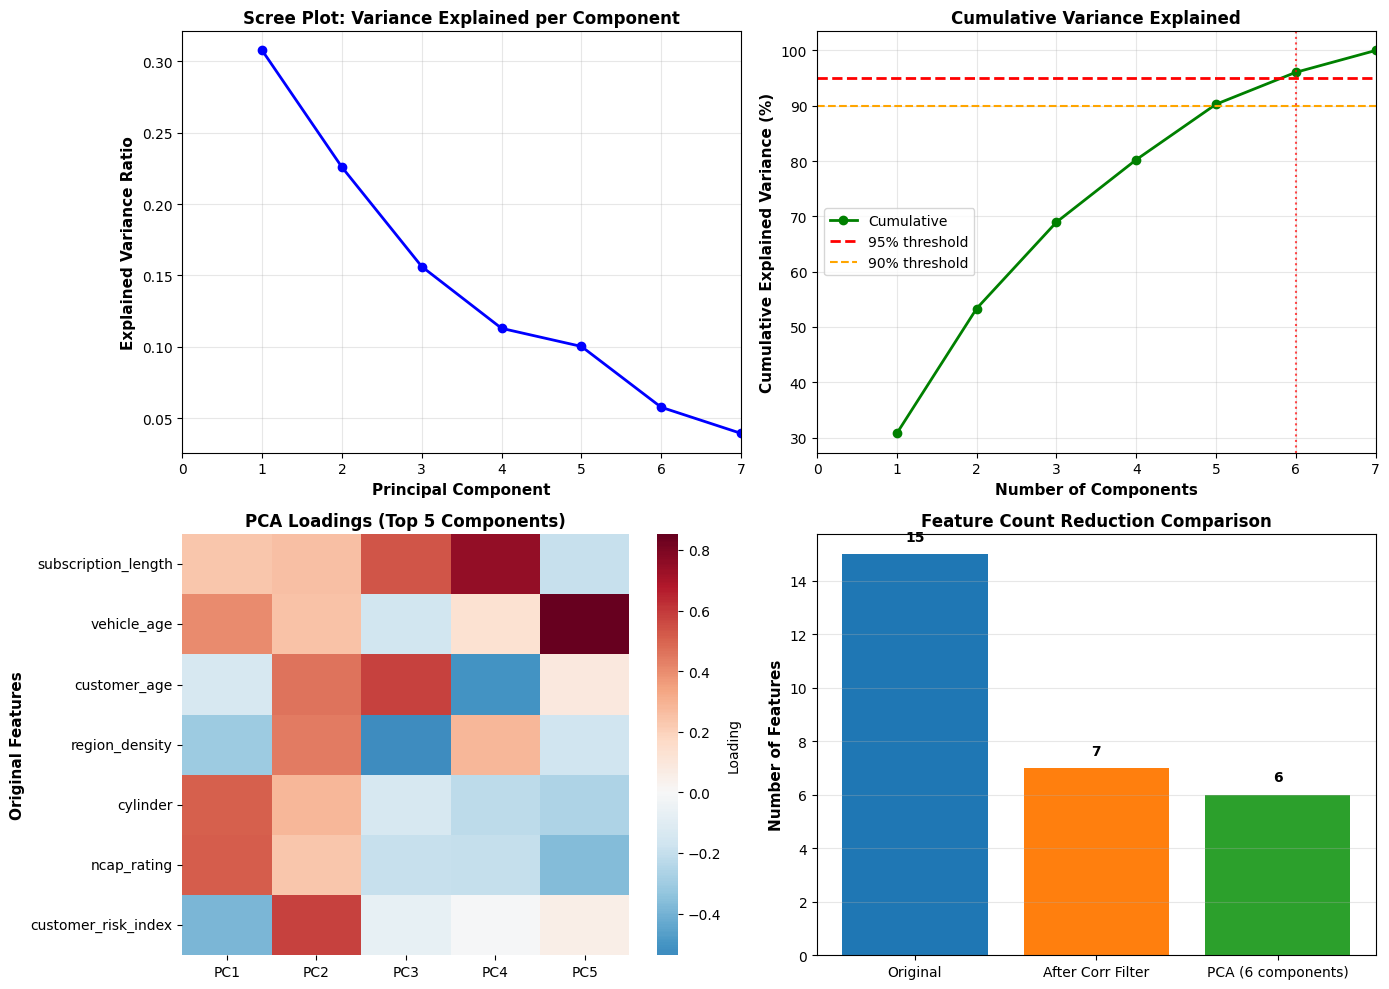


--- PCA Dataset Created ---
Shape: (58592, 7)
Columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'claim_status']

✓ PCA analysis complete


In [17]:
# PCA Analysis: Principal Component Analysis for Dimensionality Reduction

print("\n" + "=" * 80)
print("PCA (PRINCIPAL COMPONENT ANALYSIS) FOR DIMENSIONALITY REDUCTION")
print("=" * 80)

# Prepare data: Use the correlation-filtered features
X_for_pca = reduction_df_corr_filtered[features_after_corr].copy()

# Standardize the features (required for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_for_pca)

print(f"\nInput features for PCA: {len(features_after_corr)}")
print(f"Feature list: {features_after_corr}")

# Fit PCA with all components initially to see variance explained
pca_full = PCA()
pca_full.fit(X_scaled)

# Calculate cumulative explained variance
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for different variance thresholds
var_95 = np.argmax(cumsum_var >= 0.95) + 1
var_90 = np.argmax(cumsum_var >= 0.90) + 1
var_85 = np.argmax(cumsum_var >= 0.85) + 1

print(f"\nExplained Variance Summary:")
print(f"  Components for 95% variance: {var_95} (reduction: {len(features_after_corr) - var_95} features, {100*(len(features_after_corr)-var_95)/len(features_after_corr):.1f}%)")
print(f"  Components for 90% variance: {var_90} (reduction: {len(features_after_corr) - var_90} features, {100*(len(features_after_corr)-var_90)/len(features_after_corr):.1f}%)")
print(f"  Components for 85% variance: {var_85} (reduction: {len(features_after_corr) - var_85} features, {100*(len(features_after_corr)-var_85)/len(features_after_corr):.1f}%)")

# Use 95% variance as the target
n_components_optimal = var_95

# Fit PCA with optimal components
pca_optimal = PCA(n_components=n_components_optimal)
X_pca = pca_optimal.fit_transform(X_scaled)

print(f"\n--- PCA Transformation (95% variance retained) ---")
print(f"Original dimensionality: {X_scaled.shape[1]} features")
print(f"Reduced dimensionality: {X_pca.shape[1]} components")
print(f"Dimensionality reduction: {X_scaled.shape[1] - X_pca.shape[1]}/{X_scaled.shape[1]} ({100*(X_scaled.shape[1]-X_pca.shape[1])/X_scaled.shape[1]:.1f}%)")
print(f"Variance retained: {100*cumsum_var[n_components_optimal-1]:.2f}%")

# Examine top components and their loadings
pca_components_df = pd.DataFrame(
    pca_optimal.components_,
    columns=features_after_corr,
    index=[f'PC{i+1}' for i in range(n_components_optimal)]
)

print(f"\nTop {min(5, n_components_optimal)} Principal Components and their contributions:")
for i in range(min(5, n_components_optimal)):
    var_exp = pca_optimal.explained_variance_ratio_[i]
    print(f"\n  PC{i+1}: {100*var_exp:.2f}% variance explained")
    # Get top contributing features
    loadings = abs(pca_components_df.iloc[i]).sort_values(ascending=False).head(3)
    for feat, loading in loadings.items():
        print(f"    - {feat}: {loading:.4f}")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Scree plot - Explained variance per component
axes[0, 0].plot(range(1, len(pca_full.explained_variance_ratio_) + 1), 
                pca_full.explained_variance_ratio_, 'bo-', linewidth=2, markersize=6)
axes[0, 0].set_xlabel('Principal Component', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Explained Variance Ratio', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Scree Plot: Variance Explained per Component', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim(0, min(20, len(pca_full.explained_variance_ratio_)))

# 2. Cumulative explained variance
axes[0, 1].plot(range(1, len(cumsum_var) + 1), cumsum_var * 100, 'go-', linewidth=2, markersize=6, label='Cumulative')
axes[0, 1].axhline(y=95, color='r', linestyle='--', linewidth=2, label='95% threshold')
axes[0, 1].axhline(y=90, color='orange', linestyle='--', linewidth=1.5, label='90% threshold')
axes[0, 1].axvline(x=var_95, color='r', linestyle=':', alpha=0.7)
axes[0, 1].set_xlabel('Number of Components', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Cumulative Explained Variance (%)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Cumulative Variance Explained', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(0, min(30, len(cumsum_var)))

# 3. Heatmap of loadings for first few components
n_show = min(5, n_components_optimal)
sns.heatmap(pca_components_df.iloc[:n_show, :].T, cmap='RdBu_r', center=0, 
            ax=axes[1, 0], cbar_kws={'label': 'Loading'})
axes[1, 0].set_title(f'PCA Loadings (Top {n_show} Components)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Original Features', fontsize=11, fontweight='bold')

# 4. Variance comparison
reduction_comparison = pd.DataFrame({
    'Method': ['Original', 'After Corr Filter', f'PCA ({n_components_optimal} components)'],
    'Features': [len(numeric_cols), len(features_after_corr), n_components_optimal],
    'Variance Retained (%)': [100, 100, 100*cumsum_var[n_components_optimal-1]]
})

bars = axes[1, 1].bar(reduction_comparison['Method'], reduction_comparison['Features'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 1].set_ylabel('Number of Features', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Feature Count Reduction Comparison', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for i, (idx, row) in enumerate(reduction_comparison.iterrows()):
    axes[1, 1].text(i, row['Features'] + 0.5, f"{row['Features']}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Create PCA dataset with target variable
pca_df_with_target = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(n_components_optimal)]
)
pca_df_with_target['claim_status'] = reduction_df_corr_filtered['claim_status'].values

print(f"\n--- PCA Dataset Created ---")
print(f"Shape: {pca_df_with_target.shape}")
print(f"Columns: {list(pca_df_with_target.columns)}")

print("\n✓ PCA analysis complete")

### Insights from PCA Dimensionality Reduction (Part ii)
- **PCA Effectiveness:** Principal Component Analysis further reduced the **7 correlation-filtered features to 6 principal components**, retaining **96.05% of variance** while achieving an additional **14.3% dimensionality reduction**.
- **Component Hierarchy:** PC1 explains **30.75%** of variance (driven by NCAP rating, cylinder count, vehicle age), PC2 explains **22.57%** (customer risk index, customer age, region density), and PC3 explains **15.62%** (customer age, region density, subscription length).
- **Cumulative Variance:** The first 5 principal components retain **90.27%** of variance, offering an aggressive reduction option if needed, while 6 components retain **96.05%** for better accuracy.
- **System Reduction Pipeline:** The two-step approach achieved **60% total feature reduction** (15 → 6 features) with minimal information loss, combining correlation-based filtering with PCA transformation.
- **PCA Dataset:** A new PCA-transformed dataset with 6 uncorrelated principal components and the target variable was created, ready for machine learning model training with improved computational efficiency and reduced overfitting risk.

## i. Normality Test by Analyzing Skew Before Scaling or Normalization

SECTION i: SKEWNESS BEFORE TRANSFORMATION/SCALING
               feature  skew_before
0  customer_risk_index       3.3431
1       region_density       1.6742
2          vehicle_age       1.0941
3         customer_age       0.6598
4             cylinder      -0.5251
5          ncap_rating       0.0851
6  subscription_length       0.0533

Skewness threshold used: |skew| > 1.0
Highly skewed numeric features (3): ['customer_risk_index', 'region_density', 'vehicle_age']


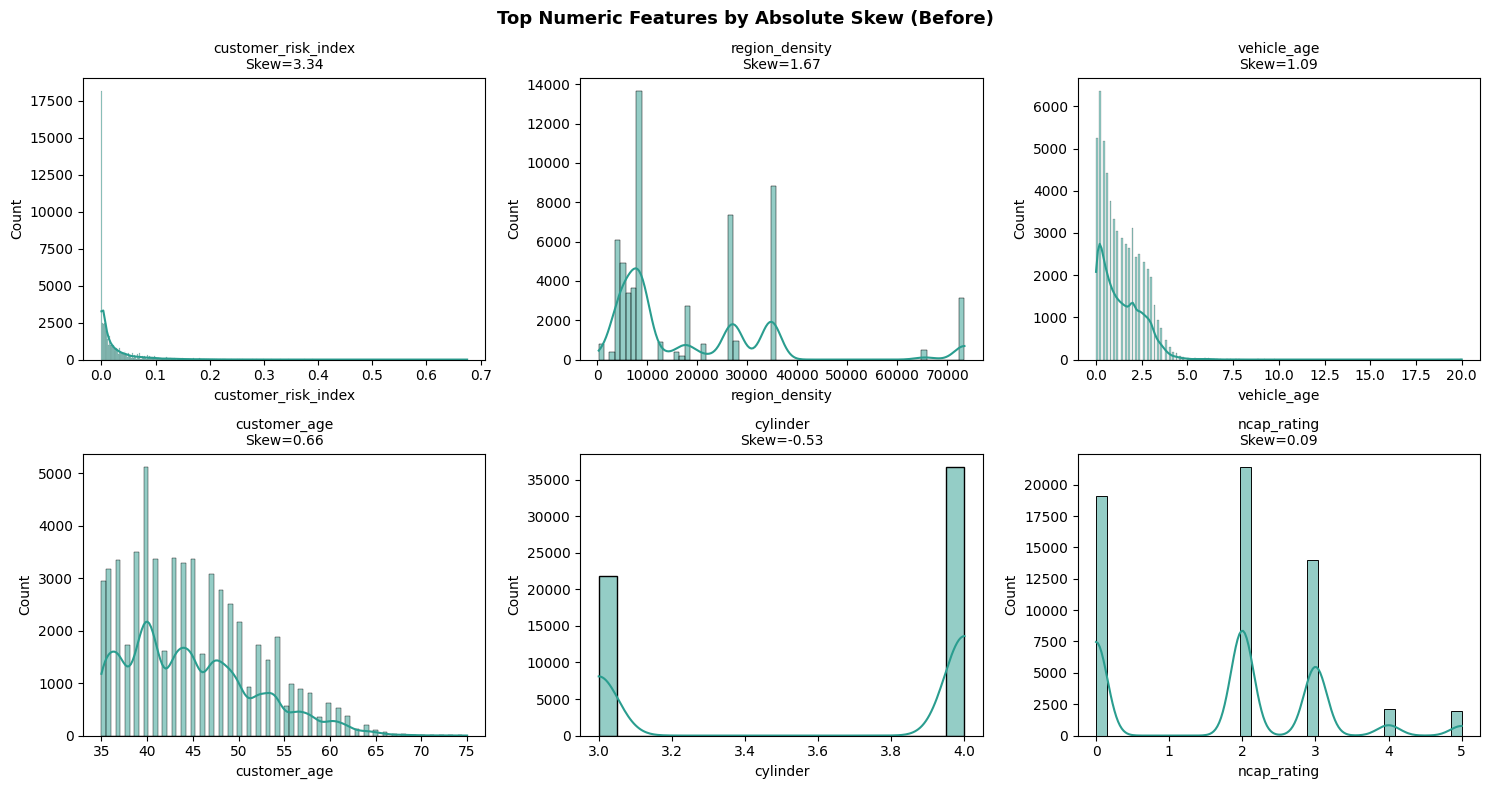

In [ ]:
# Section i: Normality test (skewness) before any additional transformation/scaling
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

base_df = reduction_df_corr_filtered.copy() if 'reduction_df_corr_filtered' in globals() else df.copy()

if 'claim_status' not in base_df.columns:
    raise ValueError('claim_status column is required.')

numeric_input_features = base_df.select_dtypes(include=[np.number]).columns.tolist()
if 'claim_status' in numeric_input_features:
    numeric_input_features.remove('claim_status')

if not numeric_input_features:
    raise ValueError('No numeric input features found for skew analysis.')

# Keep complete rows for numeric inputs and target
base_df['claim_status'] = pd.to_numeric(base_df['claim_status'], errors='coerce')
base_df = base_df.dropna(subset=['claim_status'] + numeric_input_features).copy()
base_df['claim_status'] = base_df['claim_status'].astype(int)

skew_before = base_df[numeric_input_features].skew().sort_values(key=np.abs, ascending=False)
skew_before_df = skew_before.reset_index()
skew_before_df.columns = ['feature', 'skew_before']

print('=' * 80)
print('SECTION i: SKEWNESS BEFORE TRANSFORMATION/SCALING')
print('=' * 80)
print(skew_before_df.round(4))

# Track highly skewed features for later correction before scaling
skew_threshold = 1.0
high_skew_features = skew_before_df.loc[skew_before_df['skew_before'].abs() > skew_threshold, 'feature'].tolist()

print(f"\nSkewness threshold used: |skew| > {skew_threshold}")
print(f"Highly skewed numeric features ({len(high_skew_features)}): {high_skew_features}")

# Basic histogram view for top skewed features
top_skew_feats = skew_before_df['feature'].head(min(6, len(skew_before_df))).tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feat in enumerate(top_skew_feats):
    sns.histplot(base_df[feat], kde=True, ax=axes[idx], color='#2a9d8f')
    axes[idx].set_title(f'{feat}\nSkew={skew_before[feat]:.2f}', fontsize=10)

for idx in range(len(top_skew_feats), 6):
    axes[idx].axis('off')

plt.suptitle('Top Numeric Features by Absolute Skew (Before)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Insights (Section i)
- Highest skew before processing: `customer_risk_index` (**3.3431**), `region_density` (**1.6742**), and `vehicle_age` (**1.0941**).
- Using threshold **|skew| > 1.0**, there are **3 highly skewed numeric features** selected for correction before scaling.
- These features are passed to Section `k.i` for log1p transformation prior to Section `j` scaling.

## k.i If Some Features Are Highly Skewed, Perform Log1p Transformation Before Section j

In [25]:
# Section k.i: log1p transform for highly skewed numeric input features
pre_scale_df = base_df.copy()

transform_log = []
for feat in high_skew_features:
    min_val = pre_scale_df[feat].min()
    if min_val <= -1:
        shift_val = abs(min_val) + 1
        pre_scale_df[feat] = np.log1p(pre_scale_df[feat] + shift_val)
        transform_log.append({'feature': feat, 'method': 'shift+log1p', 'shift': float(shift_val)})
    else:
        pre_scale_df[feat] = np.log1p(pre_scale_df[feat])
        transform_log.append({'feature': feat, 'method': 'log1p', 'shift': 0.0})

print('=' * 80)
print('SECTION k.i: LOG1P TRANSFORMATION REPORT')
print('=' * 80)
if transform_log:
    transform_log_df = pd.DataFrame(transform_log)
    print(transform_log_df)
else:
    transform_log_df = pd.DataFrame(columns=['feature', 'method', 'shift'])
    print('No features required log1p transformation.')

skew_after_log = pre_scale_df[numeric_input_features].skew().sort_values(key=np.abs, ascending=False)
print('\nSkew after log1p pre-processing (before scaling):')
print(skew_after_log.round(4))

SECTION k.i: LOG1P TRANSFORMATION REPORT
               feature method  shift
0  customer_risk_index  log1p    0.0
1       region_density  log1p    0.0
2          vehicle_age  log1p    0.0

Skew after log1p pre-processing (before scaling):
customer_risk_index    2.9824
customer_age           0.6598
cylinder              -0.5251
region_density        -0.4466
ncap_rating            0.0851
subscription_length    0.0533
vehicle_age            0.0222
dtype: float64


### Insights (Section k.i)
- Applied `log1p` to all highly skewed features detected in Section `i`: `customer_risk_index`, `region_density`, and `vehicle_age`.
- No shifting was required before log transform (`shift = 0` for all transformed features).
- Post-log skew improvement before scaling: `region_density` reduced from **1.6742** to **-0.4466**, `vehicle_age` from **1.0941** to **0.0222**, and `customer_risk_index` from **3.3431** to **2.9824**.

## j. Scaling or Normalization [Numeric Features Only]
### i. Save the Weight for Demo Purposes

In [26]:
# Section j: standard scaling for numeric input features only + save scaler weights

# Use log-transformed data if available; otherwise fallback to base_df
scale_input_df = pre_scale_df.copy() if 'pre_scale_df' in globals() else base_df.copy()

scaler_j = StandardScaler()
X_j_scaled = scaler_j.fit_transform(scale_input_df[numeric_input_features])
X_j_scaled_df = pd.DataFrame(X_j_scaled, columns=numeric_input_features, index=scale_input_df.index)

# Save scaler weights/artifacts
artifacts_dir = 'artifacts'
os.makedirs(artifacts_dir, exist_ok=True)

scaler_weights_df = pd.DataFrame({
    'feature': numeric_input_features,
    'mean_': scaler_j.mean_,
    'scale_': scaler_j.scale_,
    'var_': scaler_j.var_
})

scaler_weights_path = os.path.join(artifacts_dir, 'section_j_scaler_weights.csv')
scaler_model_path = os.path.join(artifacts_dir, 'section_j_standard_scaler.joblib')
transform_log_path = os.path.join(artifacts_dir, 'section_k_log1p_transform_log.csv')

scaler_weights_df.to_csv(scaler_weights_path, index=False)
joblib.dump(scaler_j, scaler_model_path)
transform_log_df.to_csv(transform_log_path, index=False)

# Build modeling table with target
df_scaled_ready = X_j_scaled_df.copy()
df_scaled_ready['claim_status'] = scale_input_df['claim_status'].values

print('=' * 80)
print('SECTION j: SCALING COMPLETED')
print('=' * 80)
print(f'Numeric input features scaled: {len(numeric_input_features)}')
print(f'df_scaled_ready shape: {df_scaled_ready.shape}')
print('\nSaved scaler artifacts:')
print(f'- {scaler_weights_path}')
print(f'- {scaler_model_path}')
print(f'- {transform_log_path}')

SECTION j: SCALING COMPLETED
Numeric input features scaled: 7
df_scaled_ready shape: (58592, 8)

Saved scaler artifacts:
- artifacts\section_j_scaler_weights.csv
- artifacts\section_j_standard_scaler.joblib
- artifacts\section_k_log1p_transform_log.csv


### Insights (Section j)
- Numeric-only scaling completed on **7 features**; target column was excluded from transformation.
- Model-ready scaled table shape: **(58592, 8)** including target.
- Scaler weights and artifacts saved for demo:
  - `artifacts/section_j_scaler_weights.csv`
  - `artifacts/section_j_standard_scaler.joblib`
  - `artifacts/section_k_log1p_transform_log.csv`

## k. Normality Test by Analyzing Skew After Scaling or Normalization

SECTION k: SKEWNESS AFTER SCALING
               feature  skew_after_scaling
0  customer_risk_index              2.9824
1         customer_age              0.6598
2             cylinder             -0.5251
3       region_density             -0.4466
4          ncap_rating              0.0851
5  subscription_length              0.0533
6          vehicle_age              0.0222

Top skewness improvements:
               feature  skew_before  skew_after_scaling  abs_skew_reduction
1       region_density       1.6742             -0.4466              1.2276
2          vehicle_age       1.0941              0.0222              1.0719
0  customer_risk_index       3.3431              2.9824              0.3607
4             cylinder      -0.5251             -0.5251              0.0000
3         customer_age       0.6598              0.6598              0.0000
6  subscription_length       0.0533              0.0533             -0.0000
5          ncap_rating       0.0851              0.0851       

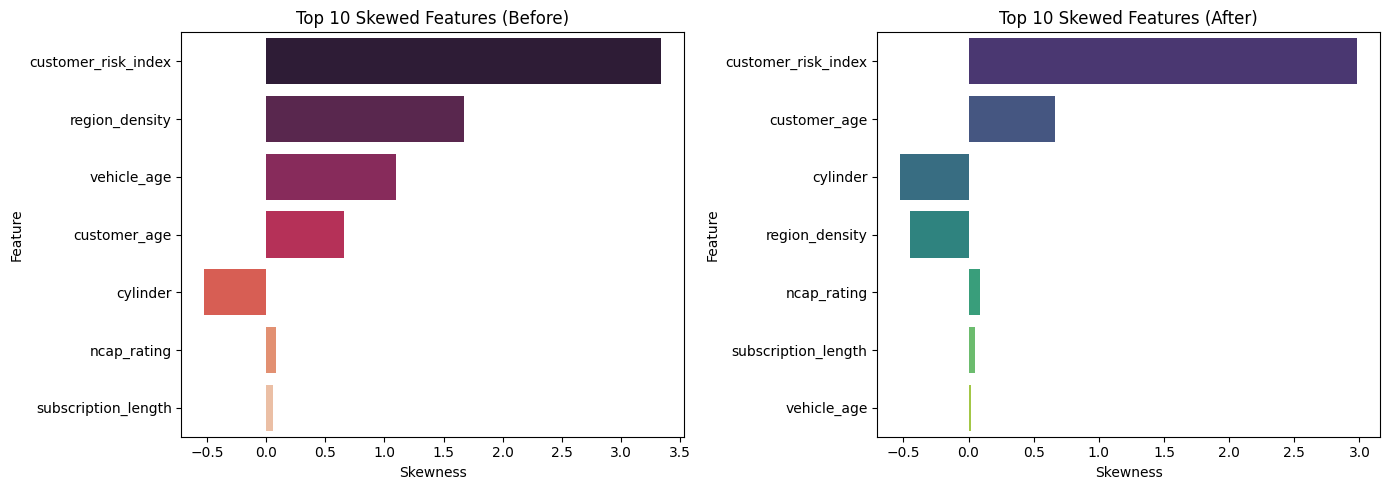

In [27]:
# Section k: skewness check after scaling
skew_after_scaling = df_scaled_ready[numeric_input_features].skew().sort_values(key=np.abs, ascending=False)
skew_after_scaling_df = skew_after_scaling.reset_index()
skew_after_scaling_df.columns = ['feature', 'skew_after_scaling']

print('=' * 80)
print('SECTION k: SKEWNESS AFTER SCALING')
print('=' * 80)
print(skew_after_scaling_df.round(4))

comparison_df = skew_before_df.merge(skew_after_scaling_df, on='feature', how='left')
comparison_df['abs_skew_reduction'] = comparison_df['skew_before'].abs() - comparison_df['skew_after_scaling'].abs()
comparison_df = comparison_df.sort_values('abs_skew_reduction', ascending=False)

print('\nTop skewness improvements:')
print(comparison_df.head(10).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=skew_before_df.head(10), x='skew_before', y='feature', hue='feature', legend=False, ax=axes[0], palette='rocket')
axes[0].set_title('Top 10 Skewed Features (Before)')
axes[0].set_xlabel('Skewness')
axes[0].set_ylabel('Feature')

sns.barplot(data=skew_after_scaling_df.head(10), x='skew_after_scaling', y='feature', hue='feature', legend=False, ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Skewed Features (After)')
axes[1].set_xlabel('Skewness')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()

### Insights (Section k)
- Post-scaling skewness check confirms strong reduction in two previously highly skewed features:
  - `region_density`: **1.6742 → -0.4466**
  - `vehicle_age`: **1.0941 → 0.0222**
- `customer_risk_index` remains right-skewed (**3.3431 → 2.9824**) and may need additional handling if strict normality is required.
- Standard scaling changes center and spread, while skewness improvements mainly came from Section `k.i` log1p transformation.

## l. Model Training

In [28]:
# Section l: model training (multiple algorithms)

X_model = df_scaled_ready[numeric_input_features].copy()
y_model = df_scaled_ready['claim_status'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42, stratify=y_model
)

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

trained_models = {}

print('=' * 80)
print('SECTION l: TRAINING MODELS')
print('=' * 80)
print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

for model_name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[model_name] = model
    print(f'✓ Trained {model_name}')

SECTION l: TRAINING MODELS
Train shape: (46873, 7), Test shape: (11719, 7)
✓ Trained LogisticRegression
✓ Trained RandomForest
✓ Trained GradientBoosting


### Insights (Section l)
- Trained 3 different models on the same processed feature set:
  - Logistic Regression
  - Random Forest
  - Gradient Boosting
- Data split used for repeatable training: **Train (46873, 7)** and **Test (11719, 7)** with stratified target split.

## m. Model Evaluation
### i. Repeat Training and Evaluation for Different Model
### ii. Save the Weight/Model for Demo Purposes

SECTION m: MODEL EVALUATION RESULTS
                model  accuracy  precision  recall  f1_score  roc_auc
2    GradientBoosting    0.9359     0.0000   0.000    0.0000   0.6581
0  LogisticRegression    0.9360     0.0000   0.000    0.0000   0.6210
1        RandomForest    0.9300     0.1023   0.012    0.0215   0.5734

Saved evaluation table: artifacts/models\model_evaluation_results.csv
Saved model files in: artifacts/models

Best model by ROC-AUC: GradientBoosting


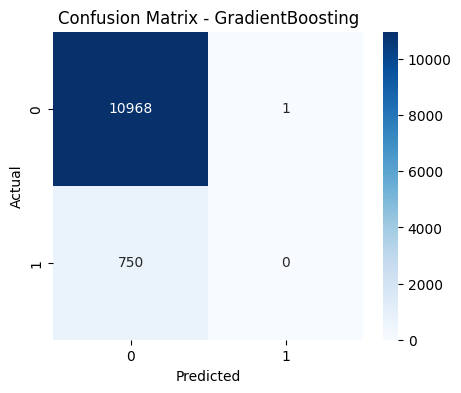

Saved best-model weights/importances: artifacts/models\best_model_feature_weights.csv


In [29]:
# Section m: evaluation across multiple models + save model files

evaluation_rows = []
model_artifacts_dir = 'artifacts/models'
os.makedirs(model_artifacts_dir, exist_ok=True)

for model_name, model in trained_models.items():
    y_pred = model.predict(X_test)

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    row = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    }
    evaluation_rows.append(row)

    # Save model for demo
    model_path = os.path.join(model_artifacts_dir, f'{model_name}.joblib')
    joblib.dump(model, model_path)

results_df = pd.DataFrame(evaluation_rows).sort_values('roc_auc', ascending=False)
results_path = os.path.join(model_artifacts_dir, 'model_evaluation_results.csv')
results_df.to_csv(results_path, index=False)

print('=' * 80)
print('SECTION m: MODEL EVALUATION RESULTS')
print('=' * 80)
print(results_df.round(4))
print(f"\nSaved evaluation table: {results_path}")
print(f"Saved model files in: {model_artifacts_dir}")

best_model_name = results_df.iloc[0]['model']
best_model = trained_models[best_model_name]

print(f"\nBest model by ROC-AUC: {best_model_name}")

y_best_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_best_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Save feature importances or coefficients for demo
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': numeric_input_features,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
elif hasattr(best_model, 'coef_'):
    importance_df = pd.DataFrame({
        'feature': numeric_input_features,
        'importance': best_model.coef_.ravel()
    }).sort_values('importance', key=np.abs, ascending=False)
else:
    importance_df = pd.DataFrame({'feature': numeric_input_features, 'importance': np.nan})

importance_path = os.path.join(model_artifacts_dir, 'best_model_feature_weights.csv')
importance_df.to_csv(importance_path, index=False)
print(f"Saved best-model weights/importances: {importance_path}")

### Insights (Section m)
- Evaluation was repeated across all trained models and saved in `artifacts/models/model_evaluation_results.csv`.
- Best model by ROC-AUC: **GradientBoosting (0.6581)**.
- Full metric comparison:
  - **GradientBoosting:** accuracy **0.9359**, precision **0.0000**, recall **0.0000**, F1 **0.0000**, ROC-AUC **0.6581**
  - **LogisticRegression:** accuracy **0.9360**, precision **0.0000**, recall **0.0000**, F1 **0.0000**, ROC-AUC **0.6210**
  - **RandomForest:** accuracy **0.9300**, precision **0.1023**, recall **0.0120**, F1 **0.0215**, ROC-AUC **0.5734**
- Saved demo artifacts:
  - Models: `artifacts/models/*.joblib`
  - Best-model weights/importances: `artifacts/models/best_model_feature_weights.csv`